# SVR Pipeline

---

In [4]:
# Libraries
import math
import json
import warnings
import hashlib

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from dataclasses import dataclass
from typing import Iterable, Optional, Literal, Any, Union

from tqdm.auto import tqdm
from tabulate import tabulate

# Machine learning
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Statistical diagnostics
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import PowerTransformer

# SciPy stats
from scipy import stats
from scipy.stats import norm, kstest
from scipy.special import inv_boxcox

warnings.filterwarnings("ignore")

d:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\MThesis_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

    - Function to format results into a table

In [5]:
def display_table(df: pd.DataFrame, title: str):
    """
    Display a formatted table for quick analysis and validation of results.

    Parameters
    ----------
    df (pd.DataFrame): DataFrame to be displayed.
    title (str): Title printed above the table.


    Returns
    -------
    df (pd.DataFrame)
    """

    print(f"\n{title}")
    if df is None:
        print("⚠️ No data provided.")
        return

    if isinstance(df, pd.Series):
        df = df.to_frame()

    if not isinstance(df, pd.DataFrame):
        print("⚠️ Invalid data format.")
        return

    if df.empty or df.shape[1] == 0:
        print("⚠️ No valid data or columns not found.")
        return

    colalign = ["center"] * len(df.columns)
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", colalign=colalign, showindex=True, floatfmt=".8f"))

    - Function to compute Freedman–Diaconis bins

In [6]:
def freedman_diaconis_bins(df: pd.DataFrame):
    """
    Compute the number of histogram bins using the Freedman–Diaconis rule.
    The FD rule sets the bin width as: width = 2 * IQR / n^(1/3), where IQR is the interquartile range (Q3 - Q1) and n is the sample size.

    Parameters
    ----------
    df (pd.DataFrame): One-dimensional numeric data.

    Returns
    -------
    n_bins (int): Suggested number of bins.
    iqr_range (float): Suggested bin IQR range.
    """

    # Length of dataframe
    n = df.size
    if n == 0:
        return print("Dataframe is empty")
    
    # IQR range calculation
    q75, q25 = np.percentile(df, [75, 25])
    iqr = q75 - q25
    iqr_range = 2.0 * iqr / (n**(1/3))

    # Bins calculation
    data_range = np.max(df) - np.min(df)
    n_bins = int(math.ceil(data_range / iqr_range)) if iqr_range > 0 else 1

    return n_bins, iqr_range

---

## Upload and verification of Time-Series data

In [7]:
# Upload of Time-Series data
def load_series_from_csv(csv_path: str | Path, value_col: str, index_col: int | str = 0, dayfirst: bool = True, sort_index: bool = True, name: str = "y"):
    """
    Load a univariate time series from a CSV file.

    Notes
    -----
    - Expects the time index in `index_col`.
    - Converts index to datetime.
    - Returns a pd.Series with a clean name.
    """
    
    csv_path = Path(csv_path)
    df_raw = pd.read_csv(csv_path, index_col=index_col)
    df_raw.index = pd.to_datetime(df_raw.index, dayfirst=dayfirst, errors="coerce")
    df_raw = df_raw.rename_axis("Date")

    if df_raw.index.isna().any():
        raise ValueError("Warning: Datetime conversion produced NaT values in the index. Please check the CSV index format.")

    if sort_index:
        if not df_raw.index.is_monotonic_increasing:
            df_raw = df_raw.sort_index()
            print("Warning: Datetime index was not sorted. It has been automatically sorted.")

    if value_col not in df_raw.columns:
        raise KeyError(f"Column '{value_col}' not found. Available columns: {list(df_raw.columns)}")

    y = df_raw[value_col].copy()
    
    y.name = name
    return y

df_path = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\BTC-USD_2025-08-15.csv"
y_temp = load_series_from_csv(csv_path= df_path, value_col= "Close", name= "Close")

# Série de valores de fecho
# y_close = y_temp.copy()
# y = y_close.copy()

# Return type and transformations
ret_type = "L"                         # "S" simple returns | "L" log returns

# Return series
if ret_type == "S":
    y_returns = pd.Series(y_temp.pct_change(), name=f"Returns({ret_type}) series").dropna()
elif ret_type == "L":
    y_returns = pd.Series(np.log(y_temp / y_temp.shift(1)), name=f"Returns({ret_type}) series").dropna()
else:
    raise ValueError("ret_type deve ser 'S' ou 'L'.")
y = y_returns.copy()

In [8]:
# Time-Series data validation
def validate_series(y: pd.Series, min_len: int = 30):
    """
    Validate basic requirements for forecasting.

    - Ensures the input is a pandas Series
    - Ensures the series is not empty
    - Ensures no missing values exist (warns and stops execution)
    - Ensures minimum length requirement
    """
    
    if not isinstance(y, pd.Series):
        raise TypeError("Input must be a pandas Series.")

    if y.empty:
        raise ValueError("Series is empty.")

    y = y.copy()

    # Coerce to numeric if needed
    y = pd.to_numeric(y, errors="coerce")

    # Check for missing values (original NaN or coercion-induced NaN)
    n_missing = int(y.isna().sum())
    if n_missing > 0:
        warnings.warn(f"Series contains {n_missing} missing values. "
                      "Missing values must be treated before running the ARIMA pipeline.", category=UserWarning)
        raise ValueError("Pipeline stopped due to missing values. "
                         "Please handle NaNs explicitly (imputation, interpolation, or removal) before proceeding.")
    else:
        print("There is no missing values on dataset, pipeline is able to continue.")


    if len(y) < min_len:
        raise ValueError(f"Series too short for ARIMA pipeline (len={len(y)} < {min_len}).")

    return y

# Execute validation
data_verification = validate_series(y=y)

There is no missing values on dataset, pipeline is able to continue.


In [9]:
# Time-Series frequenci identification
def infer_frequency(y: pd.Series):
    """
    Infer the frequency of a DatetimeIndex.
    """

    freq = pd.infer_freq(y.index)

    if freq is None:
        warnings.warn("Could not reliably infer frequency from the DatetimeIndex. "
                      "Ensure the series is regular and without missing timestamps.")
        return None

    freq_map = {"D": "Daily",
                "B": "Business Daily",
                "W": "Weekly",
                "M": "Monthly",
                "Q": "Quarterly",
                "A": "Annual"}

    # Extract main frequency code
    main_freq = freq.split("-")[0]

    readable = freq_map.get(main_freq, f"Detected frequency: {freq}")

    print(f"Detected time frequency: {readable} ({freq})")

    return freq
    
y_freq = infer_frequency(y= y)

Detected time frequency: Daily (D)


In [10]:
# Evaluate Seasonality (strength via STL)
def seasonal_strength_stl(y: pd.Series, period: int):
    """
    Compute seasonality strength using STL decomposition.

    Returns
    -------
    strength : float in [0, 1] (best-effort), or 0 if it cannot be computed.
    """

    if period is None or period < 2:
        return 0

    # Conservative guard: STL needs enough cycles
    if len(y) < 2 * period + 5:
        return 0

    try:
        stl = STL(y, period=period, robust=True).fit()
        resid = stl.resid
        seasonal_plus_resid = stl.seasonal + stl.resid

        var_resid = np.nanvar(resid)
        var_sr = np.nanvar(seasonal_plus_resid)

        if var_sr <= 0:
            return 0

        strength = 1 - (var_resid / var_sr)
        return float(np.clip(strength, 0, 1))
    
    except Exception:
        return 0


def evaluate_seasonality(y: pd.Series, candidate_periods: Optional[Iterable[int]] = None):
    """
    Evaluate a set of candidate seasonal periods and return the best one.

    Returns
    -------
    best_period : int | None
    best_strength : float
    details : dict[period -> strength]
    """

    if candidate_periods is None:
        # Generic defaults
        candidate_periods = (2, 3, 4, 5, 6, 7, 12)

    details: dict[int, float] = {}
    for p in candidate_periods:
        details[int(p)] = seasonal_strength_stl(y, int(p))

    best_period = max(details, key=details.get) if len(details) else None
    best_strength = float(details[best_period]) if best_period is not None else 0

    return best_period, best_strength, details

y_freq = infer_frequency(y)

candidate_periods = (5, 7, 15, 30, 60, 120, 365)
best_p, best_s, details = evaluate_seasonality(y, candidate_periods=candidate_periods)

print("Best seasonal period:", best_p)
print("Best seasonal strength:", round(best_s, 4))

seasonal_summary = (pd.DataFrame({"period": list(details.keys()), "strength": list(details.values())}).sort_values("strength", ascending=False).reset_index(drop=True))
seasonal_summary["period"] = seasonal_summary["period"].astype(int).astype(str)
display_table(seasonal_summary, f"Seasonal strength table of {y.name}:")

Detected time frequency: Daily (D)
Best seasonal period: 120
Best seasonal strength: 0.1291

Seasonal strength table of Returns(L) series:
╒════╤══════════╤════════════╕
│    │  period  │   strength │
╞════╪══════════╪════════════╡
│ 0  │   120    │ 0.12914079 │
├────┼──────────┼────────────┤
│ 1  │    15    │ 0.10566964 │
├────┼──────────┼────────────┤
│ 2  │   365    │ 0.09080693 │
├────┼──────────┼────────────┤
│ 3  │    30    │ 0.08894658 │
├────┼──────────┼────────────┤
│ 4  │    60    │ 0.08375077 │
├────┼──────────┼────────────┤
│ 5  │    5     │ 0.06681629 │
├────┼──────────┼────────────┤
│ 6  │    7     │ 0.05070355 │
╘════╧══════════╧════════════╛


---

In [11]:
# Time-based train/val/test split
def time_split(y: pd.Series, test_size: float = 0.2, test_start: Optional[str | pd.Timestamp] = None, val_size: float = 0.3):
    """
    Split a time series into train/val/test.

    Parameters
    ----------
    test_start : str | pd.Timestamp | None
        If provided, test starts at this timestamp (inclusive).
        If None, uses test_size percentage.
    val_size : float
        Fraction of the training portion used as validation (0 disables validation split).

    Returns
    -------
    y_train, y_val, y_test
    """
    y = y.copy()
    if test_start is not None:
        test_start = pd.to_datetime(test_start)
        y_train_full = y.loc[y.index < test_start]
        y_test = y.loc[y.index >= test_start]
        if y_train_full.empty or y_test.empty:
            raise ValueError("Date-based split produced empty train or test. Check test_start.")
    else:
        if not (0 < test_size < 1):
            raise ValueError("test_size must be in (0,1).")
        cut = int(len(y) * (1 - test_size))
        y_train_full = y.iloc[:cut]
        y_test = y.iloc[cut:]
        if y_train_full.empty or y_test.empty:
            raise ValueError("Percentage split produced empty train or test. Adjust test_size.")

    if not (0 < val_size < 1):
        raise ValueError("val_size must be in (0,1).")

    cut_val = int(len(y_train_full) * (1 - val_size))
    y_train = y_train_full.iloc[:cut_val]
    y_val = y_train_full.iloc[cut_val:]

    if y_train.empty or y_val.empty:
        raise ValueError("Validation split produced empty train or val. Adjust val_size.")

    return y_train, y_val, y_test

y_train, y_val, y_test = time_split(y= y, test_size= 0.2, test_start= None, val_size= 0.3)

print(f"Length of training dataset: {len(y_train)}")
print(f"Length of validation dataset: {len(y_val)}")
print(f"Length of test dataset: {len(y_test)}")

Length of training dataset: 2230
Length of validation dataset: 957
Length of test dataset: 797


In [12]:
# Target variable transformations
scale_transformer = None        # PowerTransformer(method="yeo-johnson", standardize=False) --- IGNORE ---
transformation_type = "original"     # "original" | "log1p" | "yeo-johnson"

# Target variable construction: volatility proxy
v_train = y_train.pow(2)
v_val = y_val.pow(2)
v_test = y_test.pow(2)

if transformation_type == "original":
    # Volatilidade proxy (squared returns)
    y_train = pd.Series(v_train, name=f"Variance_ret({ret_type}) series")
    y_val = pd.Series(v_val, name=f"Variance_ret({ret_type}) series")
    y_test = pd.Series(v_test, name=f"Variance_ret({ret_type}) series")

    serie_cache_name = y_train.name.strip("'").split()[0]

elif transformation_type == "log1p":
    scale_factor = 1e5

    v_train_scaled = v_train * scale_factor
    v_val_scaled = v_val * scale_factor
    v_test_scaled = v_test * scale_factor

    # Log transformation
    y_train = pd.Series(np.log1p(v_train_scaled), name=f"Log-Variance_ret({ret_type}) series_st")
    y_val = pd.Series(np.log1p(v_val_scaled), name=f"Log-Variance_ret({ret_type}) series_st")
    y_test = pd.Series(np.log1p(v_test_scaled), name=f"Log-Variance_ret({ret_type}) series_st")

    serie_cache_name = y_train.name.strip("'").split()[0]

elif transformation_type == "yeo-johnson":
    scale_factor = 1e5

    v_train_scaled = v_train * scale_factor
    v_val_scaled = v_val * scale_factor
    v_test_scaled = v_test * scale_factor

    # Yeo–Johnson transformation
    scale_transformer = PowerTransformer(method="yeo-johnson", standardize=False)
    y_train = pd.Series(scale_transformer.fit_transform(v_train_scaled.to_frame()).flatten(), index=v_train.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")
    y_val = pd.Series(scale_transformer.transform(v_val_scaled.to_frame()).flatten(), index=v_val.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")
    y_test = pd.Series(scale_transformer.transform(v_test_scaled.to_frame()).flatten(), index=v_test.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")

    print("Yeo-Johnson lambda:", scale_transformer.lambdas_)
    print("Train transformed - min/max:", y_train.min(), y_train.max())
    print("Validation transformed - min/max:", y_val.min(), y_val.max())
    print("Test transformed - min/max:", y_test.min(), y_test.max())

    serie_cache_name = y_train.name.strip("'").split()[0]

else:
    raise ValueError("transformation_type must be 'original', 'log1p' or 'yeo-johnson'.")

In [13]:
# Evaluate Seasonality (strength via STL)
def seasonal_strength_stl(y: pd.Series, period: int):
    """
    Compute seasonality strength using STL decomposition.

    Returns
    -------
    strength : float in [0, 1] (best-effort), or 0 if it cannot be computed.
    """

    if period is None or period < 2:
        return 0

    # Conservative guard: STL needs enough cycles
    if len(y) < 2 * period + 5:
        return 0

    try:
        stl = STL(y, period=period, robust=True).fit()
        resid = stl.resid
        seasonal_plus_resid = stl.seasonal + stl.resid

        var_resid = np.nanvar(resid)
        var_sr = np.nanvar(seasonal_plus_resid)

        if var_sr <= 0:
            return 0

        strength = 1 - (var_resid / var_sr)
        return float(np.clip(strength, 0, 1))
    
    except Exception:
        return 0


def evaluate_seasonality(y: pd.Series, candidate_periods: Optional[Iterable[int]] = None):
    """
    Evaluate a set of candidate seasonal periods and return the best one.

    Returns
    -------
    best_period : int | None
    best_strength : float
    details : dict[period -> strength]
    """

    if candidate_periods is None:
        # Generic defaults
        candidate_periods = (2, 3, 4, 5, 6, 7, 12)

    details: dict[int, float] = {}
    for p in candidate_periods:
        details[int(p)] = seasonal_strength_stl(y, int(p))

    best_period = max(details, key=details.get) if len(details) else None
    best_strength = float(details[best_period]) if best_period is not None else 0

    return best_period, best_strength, details

y_freq = infer_frequency(y.pow(2))

candidate_periods = (5, 7, 15, 30, 60, 120, 365)
best_p, best_s, details = evaluate_seasonality(y.pow(2), candidate_periods=candidate_periods)

print("Best seasonal period:", best_p)
print("Best seasonal strength:", round(best_s, 4))

seasonal_summary = (pd.DataFrame({"period": list(details.keys()), "strength": list(details.values())}).sort_values("strength", ascending=False).reset_index(drop=True))
seasonal_summary["period"] = seasonal_summary["period"].astype(int).astype(str)
display_table(seasonal_summary, f"Seasonal strength table of {y_train.name}:")

Detected time frequency: Daily (D)
Best seasonal period: 365
Best seasonal strength: 0.5148

Seasonal strength table of Variance_ret(L) series:
╒════╤══════════╤════════════╕
│    │  period  │   strength │
╞════╪══════════╪════════════╡
│ 0  │   365    │ 0.51480359 │
├────┼──────────┼────────────┤
│ 1  │    5     │ 0.07200456 │
├────┼──────────┼────────────┤
│ 2  │    60    │ 0.06347951 │
├────┼──────────┼────────────┤
│ 3  │    7     │ 0.04992226 │
├────┼──────────┼────────────┤
│ 4  │   120    │ 0.04655920 │
├────┼──────────┼────────────┤
│ 5  │    15    │ 0.03395419 │
├────┼──────────┼────────────┤
│ 6  │    30    │ 0.00000000 │
╘════╧══════════╧════════════╛


---

## Criação do modelo SVR

In [14]:
# Multi-horizon backtesting block generator (rolling/expanding) for SVR
BacktestMode = Literal["rolling", "expanding", "none"]

@dataclass(frozen=True)
class BacktestBlock:
    """
    A single origin block for multi-horizon evaluation.
    """
    origin: int
    train: pd.Series
    test: pd.Series


def generate_backtest_blocks(y: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", window: Optional[int] = None, step: int = 1):
    """
    Generate blocks for multi-horizon forecasting evaluation.

    Parameters
    ----------
    y (pd.Series): Full target series, usually the training portion only when nested splits are used.

    horizons (Iterable[int]): Forecast horizons, e.g. (1, 7, 15, 30, 120).

    mode (BacktestMode): {"rolling", "expanding", "none"}
                         Rolling: fixed training window.
                         Expanding: increasing training window from the beginning.
                         None: single origin using the provided window, or the default.

    window (int | None): Size of the training window for rolling mode, or the minimum initial window
                         for expanding/none. If None, defaults to 60% of the series length.

    step (int): Step between forecast origins.

    Returns
    -------
    blocks: list[BacktestBlock]
    """

    if not isinstance(y, pd.Series):
        raise TypeError("y must be a pandas Series.")

    y = y.copy()

    if y.empty:
        raise ValueError("y cannot be empty.")

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    n = len(y)

    if window is None:
        window = int(n * 0.60)

    if step < 1:
        raise ValueError("step must be >= 1.")

    if window < 1:
        raise ValueError("window must be >= 1.")

    # Need at least window + hmax points
    if n < window + hmax:
        raise ValueError(f"Series too short for requested horizons: need >= {window + hmax}, got {n}.")

    blocks: list[BacktestBlock] = []

    if mode == "none":
        origin = window
        train = y.iloc[:origin].copy()
        test = y.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train, test=test))
        return blocks

    # Generate multiple origins
    start_origin = window
    end_origin = n - hmax

    for origin in range(start_origin, end_origin + 1, step):

        if mode == "rolling":
            train_start = origin - window
            train = y.iloc[train_start:origin].copy()

        elif mode == "expanding":
            train = y.iloc[:origin].copy()

        else:
            raise ValueError("Invalid mode. Use 'rolling', 'expanding', or 'none'.")

        test = y.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train, test=test))

    return blocks

In [15]:
# Identify and invert transformations applied to the volatility proxy
def identify_variance_transformation_from_series_name(y: pd.Series):
    """
    Identify the transformation applied to the volatility proxy from the series name.
    The transformation is inferred from the name attribute of the input series.

    Parameters
    ----------
    y (pd.Series): Volatility-proxy series whose name identifies the applied transformation.

    Returns
    -------
    transformation (str): Identified transformation. Possible values are "original", "log1p", "yeo-johnson" or "unknown".
    """

    name = str(getattr(y, "name", ""))

    if "Yeo-Johnson-Variance_ret" in name:
        # print(y.name)
        return "yeo-johnson"

    if "Log-Variance_ret" in name:
        # print(y.name)
        return "log1p"

    if "Variance_ret" in name:
        # print(y.name)
        return "original"

    return "unknown"


def inverse_variance_transformation(values, reference_series: pd.Series, yeo_johnson_transformer: Optional[PowerTransformer] = None, clip_negative: bool = True):
    """
    Invert a transformation applied to the volatility proxy.
    Forecasts and observed values are converted back to the original volatility-proxy scale.

    Parameters
    ----------
    values (array-like): Values to invert. These may be forecasts or observed transformed values.

    reference_series (pd.Series): Series whose name identifies the transformation applied to the volatility proxy.

    yeo_johnson_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer required when the transformation is Yeo-Johnson.

    clip_negative (bool, default=True): Whether to replace negative inverted values with zero.

    Returns
    -------
    inverted (np.ndarray): Values converted to the original volatility-proxy scale.
    """

    transformation = identify_variance_transformation_from_series_name(reference_series)
    # print(f"Identified transformation for series '{reference_series.name}': {transformation}")

    values = np.asarray(values, dtype=float).reshape(-1, 1)

    if values.shape[0] == 0:
        return np.array([], dtype=float)

    if transformation == "original":
        inverted = values.flatten()

    elif transformation == "log1p":
        inverted_scaled = np.expm1(values).flatten()
        inverted = inverted_scaled / scale_factor
        inverted = np.asarray(inverted, dtype=float)
        inverted = np.where(np.isfinite(inverted), inverted, np.nan)
        
    elif transformation == "yeo-johnson":
        if yeo_johnson_transformer is None:
            raise ValueError("yeo_johnson_transformer is required for Yeo-Johnson transformation.")
        inverted_scaled = yeo_johnson_transformer.inverse_transform(values).flatten()
        inverted = inverted_scaled / scale_factor
        inverted = np.asarray(inverted, dtype=float)
        inverted = np.where(np.isfinite(inverted), inverted, np.nan)

    else:
        raise ValueError(f"Unknown transformation for series '{reference_series.name}'.")

    if clip_negative:
        inverted = np.maximum(inverted, 0)

    return inverted

In [16]:
# Metrics RMSE, MAPE, sMAPE and QLIKE
def rmse(y_true: np.ndarray, y_pred: np.ndarray):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if not np.any(mask):
        return np.nan
    
    rmse_result = float(np.sqrt(np.nanmean((y_true - y_pred) ** 2)))
    return rmse_result

def mape_smape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if not np.any(mask):
        return np.nan
    
    mape = float(np.nanmean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100)
    smape = float(np.nanmean(2 * np.abs(y_true - y_pred) / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)) * 100)
    return mape, smape

def qlike(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if not np.any(mask):
        return np.nan
    
    qlike_result = float(np.nanmean(np.log(np.maximum(y_pred, eps)) + (np.maximum(y_true, eps) / (np.maximum(y_pred, eps)))))
    return qlike_result

In [17]:
# SVR configuration dataclass
@dataclass(frozen=True)
class SVRConfig:
    """
    Configuration class for an SVR forecasting model.

    Parameters
    ----------
    n_lags (int): Number of lagged observations used as input features.

    kernel (str): Kernel type used by the SVR model.

    C (float): Regularization parameter. Higher values allow the model to fit the
               training data more closely, while lower values impose stronger regularization.

    epsilon (float): Width of the epsilon-insensitive tube. Errors smaller than epsilon are not penalized during training.

    gamma (str | float): Kernel coefficient for 'rbf', 'poly' and 'sigmoid'. Common values are 'scale', 'auto' or a positive float.

    degree (int): Degree of the polynomial kernel. Relevant only when kernel='poly'.

    coef0 (float): Independent term in the kernel function. Relevant for 'poly' and 'sigmoid'.
    """

    n_lags: int
    kernel: str = "rbf"
    C: float = 1.0
    epsilon: float = 0.1
    gamma: Union[str, float] = "scale"
    degree: int = 3
    coef0: float = 0.0

    def to_dict(self):
        """
        Convert the configuration into a dictionary.
        """

        return {"n_lags": self.n_lags,
                "kernel": self.kernel,
                "C": self.C,
                "epsilon": self.epsilon,
                "gamma": self.gamma,
                "degree": self.degree,
                "coef0": self.coef0}

    def to_label(self):
        """
        Build a compact human-readable label for tables and logs.
        """

        return (f"SVR(lags={self.n_lags}, "
                f"kernel='{self.kernel}', "
                f"C={self.C}, "
                f"epsilon={self.epsilon}, "
                f"gamma={self.gamma}, "
                f"degree={self.degree}, "
                f"coef0={self.coef0})")

In [18]:
# SVR configuration grid builder
def build_svr_config_grid(n_lags_values: Iterable[int] = (3, 5, 7, 10, 14, 21, 30, 60), kernel_values: Iterable[str] = ("linear", "rbf", "poly", "sigmoid"),
                          C_values: Iterable[float] = (0.1, 1, 10, 100), epsilon_values: Iterable[float] = (0.001, 0.01, 0.1),
                          gamma_values: Iterable[Union[str, float]] = ("scale", "auto",), degree_values: Iterable[int] = (2, 3,),
                          coef0_values: Iterable[float] = (0, 0.5, 1,)):
    """
    Build a compact SVR configuration grid.

    Parameters
    ----------
    n_lags_values (Iterable[int]): Candidate numbers of lagged observations used as input features.

    kernel_values (Iterable[str]): Candidate SVR kernels.

    C_values (Iterable[float]): Candidate regularization parameters.

    epsilon_values (Iterable[float]): Candidate widths of the epsilon-insensitive tube.

    gamma_values (Iterable[str | float]): Candidate kernel coefficients for "linear", "rbf", "poly" and "sigmoid".

    degree_values (Iterable[int]): Candidate polynomial degrees.

    coef0_values (Iterable[float]): Candidate independent terms in the kernel function.

    Returns
    -------
    grid (list[SVRConfig]): List of SVR configurations.
    """

    valid_kernels = {"linear", "rbf", "poly", "sigmoid"}
    grid = []

    for n_lags in n_lags_values:
        for kernel in kernel_values:

            kernel = str(kernel)

            if kernel not in valid_kernels:
                raise ValueError(f"Invalid kernel '{kernel}'. "
                                 f"Valid options are {sorted(valid_kernels)}.")

            for C in C_values:
                for epsilon in epsilon_values:

                    if kernel == "linear":
                        grid.append(SVRConfig(n_lags=int(n_lags),
                                              kernel=kernel,
                                              C=float(C),
                                              epsilon=float(epsilon),
                                              gamma="scale",
                                              degree=3,
                                              coef0=0))

                    elif kernel == "rbf":
                        for gamma in gamma_values:
                            grid.append(SVRConfig(n_lags=int(n_lags),
                                                  kernel=kernel,
                                                  C=float(C),
                                                  epsilon=float(epsilon),
                                                  gamma=gamma,
                                                  degree=3,
                                                  coef0=0))

                    elif kernel == "poly":
                        for gamma in gamma_values:
                            for degree in degree_values:
                                for coef0 in coef0_values:
                                    grid.append(SVRConfig(n_lags=int(n_lags),
                                                          kernel=kernel,
                                                          C=float(C),
                                                          epsilon=float(epsilon),
                                                          gamma=gamma,
                                                          degree=int(degree),
                                                          coef0=float(coef0)))

                    elif kernel == "sigmoid":
                        for gamma in gamma_values:
                            for coef0 in coef0_values:
                                grid.append(SVRConfig(n_lags=int(n_lags),
                                                      kernel=kernel,
                                                      C=float(C),
                                                      epsilon=float(epsilon),
                                                      gamma=gamma,
                                                      degree=3,
                                                      coef0=float(coef0)))

    return grid

In [19]:
# SVR configuration compatibility check
def svr_config_compatible(y: pd.Series, cfg: SVRConfig, hmax: int = 1, min_samples: int = 10):
    """
    Enforce basic SVR constraints to avoid unnecessary exceptions.

    Parameters
    ----------
    y (pd.Series): Time series used to create SVR lagged features.

    cfg (SVRConfig): SVR configuration.

    hmax (int, default=1): Maximum forecast horizon required when creating supervised samples.

    min_samples (int, default=10): Minimum number of supervised samples required after applying n_lags.

    Returns
    -------
    bool: True if the configuration is compatible with the available data.
    """

    if not isinstance(y, pd.Series):
        return False

    if len(y) == 0:
        return False

    if cfg.n_lags < 1:
        return False

    valid_kernels = {"linear", "rbf", "poly", "sigmoid"}

    if cfg.kernel not in valid_kernels:
        return False

    if cfg.C <= 0:
        return False

    if cfg.epsilon < 0:
        return False

    if isinstance(cfg.gamma, str):
        if cfg.gamma not in {"scale", "auto"}:
            return False
    else:
        try:
            if float(cfg.gamma) <= 0:
                return False
        except Exception:
            return False

    if cfg.degree < 1:
        return False

    if hmax < 1:
        return False

    n_samples = len(y) - cfg.n_lags - hmax + 1

    if n_samples < min_samples:
        return False

    return True

In [20]:
# Create supervised SVR features
def make_svr_features(y: pd.Series, n_lags: int, horizons: tuple[int, ...]):
    """
    Convert a univariate time series into a supervised learning dataset for SVR.

    Parameters
    ----------
    y (pd.Series): Input time series.

    n_lags (int): Number of past observations used as input features.

    horizons (tuple[int, ...]): Forecast horizons to predict, e.g. (1, 7, 15, 30, 120).

    Returns
    -------
    x (pd.DataFrame): Lagged input features with shape (n_samples, n_lags).

    y (pd.DataFrame): Multi-horizon targets with shape (n_samples, n_horizons).

    target_index (pd.Index): Dates associated with the first forecast horizon.
    """

    if not isinstance(y, pd.Series):
        raise TypeError("y must be a pandas Series.")

    if n_lags < 1:
        raise ValueError("n_lags must be greater than or equal to 1.")

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    values = y.to_numpy(dtype=float)
    index = y.index

    hmax = max(horizons)

    x_rows, y_rows, target_dates = [], [], []

    for i in range(n_lags, len(values) - hmax + 1):
        x_i = values[i - n_lags:i][::-1]
        y_i = [values[i + h - 1] for h in horizons]

        x_rows.append(x_i)
        y_rows.append(y_i)
        target_dates.append(index[i])

    if len(x_rows) == 0:
        raise ValueError("No SVR supervised samples were created. Check n_lags, horizons and series length.")

    x_cols = [f"lag_{lag}" for lag in range(1, n_lags + 1)]
    y_cols = [f"target_h={h}" for h in horizons]

    x = pd.DataFrame(np.asarray(x_rows, dtype=float), index=pd.Index(target_dates), columns=x_cols)

    y = pd.DataFrame(np.asarray(y_rows, dtype=float), index=pd.Index(target_dates), columns=y_cols)

    target_index = pd.Index(target_dates)

    return x, y, target_index

In [21]:
# Build SVR model
def build_svr_model(cfg: SVRConfig):
    """
    Build an SVR model from a given configuration.

    Parameters
    ----------
    cfg (SVRConfig): SVR configuration.

    Returns
    -------
    model (sklearn.svm.SVR): SVR model.
    """

    valid_kernels = {"linear", "rbf", "poly", "sigmoid"}

    if cfg.kernel not in valid_kernels:
        raise ValueError(f"Unsupported SVR kernel: {cfg.kernel}. Valid kernels are {sorted(valid_kernels)}.")

    model = SVR(kernel=cfg.kernel, C=cfg.C, epsilon=cfg.epsilon, gamma=cfg.gamma, degree=cfg.degree, coef0=cfg.coef0)

    return model

In [22]:
# Fit SVR models and forecast the next multi-horizon values
def forecast_svr(y_train: pd.Series, horizons: tuple[int, ...], cfg: SVRConfig, scaler_type: str = "standard"):
    """
    Fit direct multi-horizon SVR models and forecast the requested horizons.

    One independent SVR model is fitted for each forecast horizon.

    Parameters
    ----------
    y_train (pd.Series): Historical series available up to the forecast origin.

    horizons (tuple[int, ...]): Forecast horizons, e.g. (1, 7, 15, 30, 120).

    cfg (SVRConfig): SVR configuration.

    scaler_type (str, default="standard"): Scaling method. Currently supports "standard" and "minmax".

    Returns
    -------
    y_hat (np.ndarray): Forecasts for the requested horizons, aligned with horizons.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if not svr_config_compatible(y=y_train, cfg=cfg, hmax=hmax, min_samples=10):
        raise ValueError(f"SVR configuration is not compatible with y_train: {cfg.to_label()}")

    y_train = y_train.copy()

    if scaler_type == "standard":
        scaler = StandardScaler()
    elif scaler_type == "minmax":
        scaler = MinMaxScaler()
    else:
        raise ValueError("scaler_type must be either 'standard' or 'minmax'.")

    # Fit scaler only on the available training/history data.
    scaler.fit(y_train.to_numpy(dtype=float).reshape(-1, 1))

    y_train_scaled = pd.Series(scaler.transform(y_train.to_numpy(dtype=float).reshape(-1, 1)).flatten(), index=y_train.index, name=y_train.name)

    # Create supervised training data using only y_train.
    x_train, y_train_supervised, _ = make_svr_features(y=y_train_scaled, n_lags=cfg.n_lags, horizons=horizons)

    # Forecast from the last available lag window in y_train.
    last_window_scaled = (y_train_scaled.iloc[-cfg.n_lags:].to_numpy(dtype=float)[::-1])

    x_forecast = pd.DataFrame([last_window_scaled], columns=[f"lag_{lag}" for lag in range(1, cfg.n_lags + 1)])

    y_hat_scaled = []

    for h in horizons:
        target_col = f"target_h={h}"

        model = build_svr_model(cfg)

        model.fit(x_train, y_train_supervised[target_col].to_numpy(dtype=float))

        pred_h_scaled = model.predict(x_forecast)[0]
        y_hat_scaled.append(pred_h_scaled)

    y_hat_scaled = np.asarray(y_hat_scaled, dtype=float)

    # Inverse transform each horizon forecast.
    y_hat = scaler.inverse_transform(y_hat_scaled.reshape(-1, 1)).flatten()

    return np.asarray(y_hat, dtype=float)

In [23]:
# Evaluate a list of SVR configs on a single origin
def evaluate_svr_configs_single_origin(y_train: pd.Series, y_test_hmax: pd.Series, cfgs: list[SVRConfig], horizons: Iterable[int], scaler_type: str = "standard", metric: str = "RMSE",
                                       min_samples: int = 30, scale_transformer: Optional[PowerTransformer] = None, origin: Optional[int] = None,
                                       origin_date: Optional[pd.Timestamp] = None):
    """
    Evaluate a fixed list of SVR configurations on a single forecast origin.

    Each SVR configuration is fitted using only y_train, and forecasts are produced
    directly for the specified horizons. Since sklearn's SVR is single-output,
    forecast_svr() fits one SVR model per horizon.

    Parameters
    ----------
    y_train (pd.Series): Time series available up to the forecast origin.

    y_test_hmax (pd.Series): Future observations after the forecast origin.
                             Must contain at least max(horizons) observations.

    cfgs (list[SVRConfig]): List of SVR configurations to evaluate.

    horizons (Iterable[int]): Forecast horizons, for example (1, 7, 15, 30, 120).

    scaler_type (str, default="standard"): Scaling method used inside the SVR forecasting function.

    metric (str, default="RMSE"): Main metric used to rank configurations.
                                  Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    min_samples (int, default=30): Minimum number of supervised samples required for a configuration.

    scale_transformer (PowerTransformer, optional): Required if the target series
                                                           uses a Yeo-Johnson transformation.

    origin (int, optional): Forecast origin position.

    origin_date (pd.Timestamp, optional): Forecast origin date.

    Returns
    -------
    df_metrics (pd.DataFrame): DataFrame with configuration parameters, per-horizon metrics and aggregate scores.
    df_forecasts (pd.DataFrame): DataFrame with point forecasts, observed values and residuals by configuration and horizon.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_test_hmax) < hmax:
        raise ValueError(f"y_test_hmax must contain at least {hmax} observations. Got {len(y_test_hmax)}.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    y_train = y_train.copy()
    y_test_hmax_input = y_test_hmax.iloc[:hmax].copy()

    if len(y_train) == 0 or len(y_test_hmax_input) < hmax:
        raise ValueError("Empty or insufficient train/test data after preprocessing.")

    if not np.all(np.isfinite(y_train.to_numpy(dtype=float))):
        raise ValueError("y_train contains NaN or infinite values.")

    if not np.all(np.isfinite(y_test_hmax_input.to_numpy(dtype=float))):
        raise ValueError("y_test_hmax contains NaN or infinite values within the required horizon window.")

    # Future observations in the input scale, limited to hmax
    y_test_hmax_values = y_test_hmax_input.values.astype(float)

    # Invert observed future values to original volatility-proxy scale
    y_test_hmax_original = inverse_variance_transformation(values=y_test_hmax_values,
                                                           reference_series=y_test_hmax,
                                                           yeo_johnson_transformer=scale_transformer,
                                                           clip_negative=True)

    metric_rows = []
    forecast_rows = []

    for cfg in cfgs:

        if not svr_config_compatible(y=y_train, cfg=cfg, hmax=hmax, min_samples=min_samples):
            continue

        try:
            # Forecasts are returned in the same scale as y_train.
            y_hat = forecast_svr(y_train=y_train, horizons=horizons, cfg=cfg, scaler_type=scaler_type)

            y_hat_values = np.asarray(y_hat, dtype=float)

            # Invert forecasts to original volatility-proxy scale
            y_hat_original = inverse_variance_transformation(values=y_hat_values,
                                                             reference_series=y_train,
                                                             yeo_johnson_transformer=scale_transformer,
                                                             clip_negative=True)

            row = {"n_lags": cfg.n_lags,
                   "kernel": cfg.kernel,
                   "C": cfg.C,
                   "epsilon": cfg.epsilon,
                   "gamma": cfg.gamma,
                   "degree": cfg.degree,
                   "coef0": cfg.coef0}

            rmse_list = []
            mape_list = []
            smape_list = []
            qlike_list = []

            for idx, h in enumerate(horizons):

                y_true = np.asarray([y_test_hmax_original[h - 1]], dtype=float)
                y_pred = np.asarray([y_hat_original[idx]], dtype=float)

                row[f"RMSE-h={h}"] = rmse(y_true, y_pred)
                row[f"MAPE-h={h}"], row[f"SMAPE-h={h}"] = mape_smape(y_true, y_pred)
                row[f"QLIKE-h={h}"] = qlike(y_true, y_pred)

                rmse_list.append(row[f"RMSE-h={h}"])
                mape_list.append(row[f"MAPE-h={h}"])
                smape_list.append(row[f"SMAPE-h={h}"])
                qlike_list.append(row[f"QLIKE-h={h}"])

                y_true_h = float(y_test_hmax_original[h - 1])
                y_pred_h = float(y_hat_original[idx])

                forecast_rows.append({"origin": origin,
                                      "origin_date": origin_date,
                                      "n_lags": cfg.n_lags,
                                      "kernel": cfg.kernel,
                                      "C": cfg.C,
                                      "epsilon": cfg.epsilon,
                                      "gamma": cfg.gamma,
                                      "degree": cfg.degree,
                                      "coef0": cfg.coef0,
                                      "horizon": int(h),
                                      "y_true_vol_proxy": y_true_h,
                                      "forecast": y_pred_h,
                                      "residual": y_true_h - y_pred_h})

            row["score_rmse_mean"] = float(np.nanmean(rmse_list))
            row["score_mape_mean"] = float(np.nanmean(mape_list))
            row["score_smape_mean"] = float(np.nanmean(smape_list))
            row["score_qlike_mean"] = float(np.nanmean(qlike_list))

            if metric == "RMSE":
                row["score_selected"] = row["score_rmse_mean"]
            elif metric == "MAPE":
                row["score_selected"] = row["score_mape_mean"]
            elif metric == "SMAPE":
                row["score_selected"] = row["score_smape_mean"]
            elif metric == "QLIKE":
                row["score_selected"] = row["score_qlike_mean"]

            metric_rows.append(row)

        except Exception:
            continue

    df_metrics = pd.DataFrame(metric_rows)
    df_forecasts = pd.DataFrame(forecast_rows)

    if not df_metrics.empty:
        df_metrics = df_metrics.sort_values("score_selected", ascending=True).reset_index(drop=True)

    return df_metrics, df_forecasts

In [24]:
# SVR CV within training set and aggregate results
def svr_cv_train_select(y_train: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", step: int = 1, n_lags_values: Iterable[int] = (3, 5, 7, 10, 14, 21, 30, 60),
                        kernel_values: Iterable[str] = ("linear", "rbf", "poly", "sigmoid"), C_values: Iterable[float] = (1, 10, 100), epsilon_values: Iterable[float] = (0.01, 0.1),
                        gamma_values: Iterable[Union[str, float]] = ("scale", "auto"), degree_values: Iterable[int] = (2, 3), coef0_values: Iterable[float] = (0, 1),
                        scaler_type: str = "standard", metric: str = "RMSE", top_k: int = 10, min_samples: int = 30, scale_transformer: Optional[PowerTransformer] = None):
    """
    Apply cross-validation only within the training set using rolling or expanding blocks,
    aggregate results per SVR configuration, and return a compact package of outputs.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    hmax = max(horizons)

    y_train_cv = y_train.copy()

    if len(y_train_cv) <= hmax:
        raise ValueError(f"Training series too short for the requested horizons. Need more than hmax={hmax} observations.")

    max_n_lags = max(int(v) for v in n_lags_values)

    # Window for CV blocks.
    # It must be large enough to create SVR supervised samples.
    train_w = int(len(y_train_cv) * 0.6)
    train_w = max(train_w, max_n_lags + hmax + min_samples)
    train_w = min(train_w, len(y_train_cv) - hmax)

    if train_w <= max_n_lags + hmax:
        raise ValueError(f"Training window too small for SVR CV. train_w={train_w}, max_n_lags={max_n_lags}, hmax={hmax}.")

    blocks = generate_backtest_blocks(y=y_train_cv, horizons=horizons, mode=mode, window=train_w, step=step)

    cfgs = build_svr_config_grid(n_lags_values=n_lags_values,
                                 kernel_values=kernel_values,
                                 C_values=C_values,
                                 epsilon_values=epsilon_values,
                                 gamma_values=gamma_values,
                                 degree_values=degree_values,
                                 coef0_values=coef0_values)

    compatible_cfgs = [cfg for cfg in cfgs if svr_config_compatible(y=y_train_cv, cfg=cfg, hmax=hmax, min_samples=min_samples)]

    per_origin = []
    per_origin_forecasts = []

    for b in tqdm(blocks, desc="SVR CV (train) - origins", unit="origin"):

        origin_date = getattr(b, "origin_date", None)

        if origin_date is None:
            try:
                origin_date = y_train_cv.index[b.origin]
            except Exception:
                origin_date = None

        df_origin, df_forecast_origin = evaluate_svr_configs_single_origin(y_train=b.train,
                                                                           y_test_hmax=b.test,
                                                                           cfgs=compatible_cfgs,
                                                                           horizons=horizons,
                                                                           scaler_type=scaler_type,
                                                                           metric=metric,
                                                                           min_samples=min_samples,
                                                                           scale_transformer=scale_transformer,
                                                                           origin=b.origin,
                                                                           origin_date=origin_date)

        if not df_origin.empty:
            df_origin["origin"] = b.origin
            df_origin["origin_date"] = origin_date
            per_origin.append(df_origin)

        if not df_forecast_origin.empty:
            per_origin_forecasts.append(df_forecast_origin)

    df_all = (pd.concat(per_origin, ignore_index=True) if len(per_origin) else pd.DataFrame())

    df_forecasts_train = (pd.concat(per_origin_forecasts, ignore_index=True) if len(per_origin_forecasts) else pd.DataFrame())

    if df_all.empty:
        summary = pd.DataFrame()
        top = pd.DataFrame()

    else:
        if "score_selected" in df_all.columns:
            df_all_valid = df_all[df_all["score_selected"].notna()].copy()
        else:
            df_all_valid = pd.DataFrame()

        if df_all_valid.empty:
            summary = pd.DataFrame()
            top = pd.DataFrame()

        else:
            group_cols = ["n_lags", "kernel", "C", "epsilon", "gamma", "degree", "coef0"]

            rmse_cols = sorted([c for c in df_all_valid.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
            mape_cols = sorted([c for c in df_all_valid.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
            smape_cols = sorted([c for c in df_all_valid.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
            qlike_cols = sorted([c for c in df_all_valid.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

            metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"])
            metric_cols = [c for c in metric_cols if c in df_all_valid.columns]

            summary = (df_all_valid.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

            top = summary.head(top_k).copy()

    return {"y_train_cv": y_train_cv,
            "train_w": train_w,
            "hmax": hmax,
            "blocks_n": len(blocks),
            "cfgs_n": len(cfgs),
            "compatible_cfgs_n": len(compatible_cfgs),
            "df_all_train": df_all,
            "df_forecasts_train": df_forecasts_train,
            "summary_train": summary,
            "top_train": top}

---

# Avaliação no conjunto de Treino

In [25]:
# Caching mechanism for SVR CV results on training set
def run_or_load_svr_train_search(cache_dir: str, cache_name: str, y_train: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", step: int = 1,
                                 n_lags_values: Iterable[int] = (3, 5, 7, 10, 14, 21, 30, 60), kernel_values: Iterable[str] = ("linear", "rbf", "poly", "sigmoid"),
                                 C_values: Iterable[float] = (1, 10, 100), epsilon_values: Iterable[float] = (0.01, 0.1), gamma_values: Iterable[Union[str, float]] = ("scale", "auto"),
                                 degree_values: Iterable[int] = (2, 3), coef0_values: Iterable[float] = (0, 1), scaler_type: str = "standard", metric: str = "RMSE",
                                 top_k: int = 10, min_samples: int = 30, scale_transformer: Optional[PowerTransformer] = None):
    """
    Run SVR cross-validation on the training set or load cached results from disk.

    The cache is only loaded when the metadata match the current input data, horizons,
    backtesting setup, SVR hyperparameter grid, scaling setup and inverse-transformation setup.

    Parameters
    ----------
    cache_dir (str): Directory where training CV results are stored.

    cache_name (str): Cache folder name for the current SVR training run.

    y_train (pd.Series): Training time series used for SVR cross-validation.

    horizons (Iterable[int]): Forecast horizons, for example (1, 7, 15, 30, 120).

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate forecast-origin blocks.

    step (int, default=1): Step between forecast origins.

    n_lags_values (Iterable[int]): Candidate numbers of lagged observations used as predictors.

    kernel_values (Iterable[str]): Candidate SVR kernels.

    C_values (Iterable[float]): Candidate regularisation parameters.

    epsilon_values (Iterable[float]): Candidate epsilon values for the epsilon-insensitive loss.

    gamma_values (Iterable[str | float]): Candidate gamma values used by nonlinear kernels.

    degree_values (Iterable[int]): Candidate polynomial degrees used when the polynomial kernel is selected.

    coef0_values (Iterable[float]): Candidate independent terms used by polynomial and sigmoid kernels.

    scaler_type (str, default="standard"): Scaling method used inside the SVR forecasting function.

    metric (str, default="RMSE"): Main metric used for ranking configurations. Supported values depend on the SVR evaluation function, typically "RMSE", "MAPE", "SMAPE", and "QLIKE".

    top_k (int, default=10): Number of top configurations to return.

    min_samples (int, default=30): Minimum number of supervised samples required.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer required when the target series uses a Yeo-Johnson transformation.

    Returns
    -------
    out (dict): Dictionary containing cached or newly computed SVR training CV results, forecasts and metadata.
    """

    def series_signature(y: pd.Series):
        """
        Create a deterministic signature for the input series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    def normalize_list(values):
        """
        Convert iterable values into JSON-compatible lists.
        """
        out = []

        for v in values:
            if v is None:
                out.append(None)
            elif isinstance(v, (int, float, str, bool)):
                out.append(v)
            else:
                out.append(str(v))

        return out

    def transformer_signature(transformer):
        """
        Create a simple signature for the fitted transformation object.

        This is especially relevant for Yeo-Johnson, because the inverse
        transformation depends on the fitted transformer parameters.
        """
        if transformer is None:
            return None

        try:
            params = {"class": transformer.__class__.__name__,
                      "lambdas": getattr(transformer, "lambdas_", None).tolist()
                      if hasattr(transformer, "lambdas_") else None,
                      "standardize": getattr(transformer, "standardize", None),
                      "method": getattr(transformer, "method", None)}

            encoded = json.dumps(params, sort_keys=True).encode("utf-8")
            return hashlib.sha256(encoded).hexdigest()

        except Exception:
            return str(transformer)

    def safe_transformation_name(y: pd.Series):
        """
        Identify the transformation used in the volatility-proxy series.
        Falls back to 'unknown' if the helper function is not available.
        """
        try:
            return identify_variance_transformation_from_series_name(y)
        except Exception:
            return "unknown"

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    df_all_file = cache_path / "df_all_train.pkl.gz"
    summary_file = cache_path / "summary_train.pkl.gz"
    top_file = cache_path / "top_train.pkl.gz"
    df_forecasts_file = cache_path / "df_forecasts_train.pkl.gz"

    horizons_clean = list(sorted(set(int(h) for h in horizons)))
    metric_clean = str(metric).upper()
    target_transformation = safe_transformation_name(y_train)

    expected_meta = {"model": "SVR",

                     "horizons": horizons_clean,
                     "mode": str(mode),
                     "step": int(step),

                     # SVR hyperparameter grid
                     "n_lags_values": normalize_list(n_lags_values),
                     "kernel_values": normalize_list(kernel_values),
                     "C_values": normalize_list(C_values),
                     "epsilon_values": normalize_list(epsilon_values),
                     "gamma_values": normalize_list(gamma_values),
                     "degree_values": normalize_list(degree_values),
                     "coef0_values": normalize_list(coef0_values),

                     "scaler_type": str(scaler_type),
                     "metric": metric_clean,
                     "top_k": int(top_k),
                     "min_samples": int(min_samples),

                     # Critical transformation metadata
                     "target_transformation": str(target_transformation),
                     "scale_transformer_signature": transformer_signature(scale_transformer),

                     # Series identity
                     "series_signature": series_signature(y_train),
                     "series_length": int(len(y_train)),
                     "series_start": str(y_train.index.min()),
                     "series_end": str(y_train.index.max()),

                     # Forecast storage
                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy"}

    required_files_exist = (meta_file.exists()
                            and df_all_file.exists()
                            and summary_file.exists()
                            and top_file.exists()
                            and df_forecasts_file.exists())

    if required_files_exist:
        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        keys_to_check = ["model",

                         "horizons",
                         "mode",
                         "step",

                         "n_lags_values",
                         "kernel_values",
                         "C_values",
                         "epsilon_values",
                         "gamma_values",
                         "degree_values",
                         "coef0_values",

                         "scaler_type",
                         "metric",
                         "top_k",
                         "min_samples",

                         "target_transformation",
                         "scale_transformer_signature",

                         "series_signature",
                         "series_length",
                         "series_start",
                         "series_end",

                         "stored_forecasts",
                         "forecast_scale"]

        cache_is_valid = all(meta.get(k) == expected_meta[k] for k in keys_to_check)

        if cache_is_valid:
            out = {"y_train_cv": y_train.copy(),
                   "train_w": meta["train_w"],
                   "hmax": meta["hmax"],
                   "blocks_n": meta["blocks_n"],
                   "cfgs_n": meta["cfgs_n"],
                   "compatible_cfgs_n": meta["compatible_cfgs_n"],
                   "df_all_train": pd.read_pickle(df_all_file, compression="gzip"),
                   "summary_train": pd.read_pickle(summary_file, compression="gzip"),
                   "top_train": pd.read_pickle(top_file, compression="gzip"),
                   "df_forecasts_train": pd.read_pickle(df_forecasts_file, compression="gzip"),
                   "meta": meta}

            return out

        print("Warning: cache metadata does not match current input. Recomputing SVR CV.")

    # Otherwise run SVR CV
    out = svr_cv_train_select(y_train=y_train,
                              horizons=horizons_clean,
                              mode=mode,
                              step=step,
                              n_lags_values=n_lags_values,
                              kernel_values=kernel_values,
                              C_values=C_values,
                              epsilon_values=epsilon_values,
                              gamma_values=gamma_values,
                              degree_values=degree_values,
                              coef0_values=coef0_values,
                              scaler_type=scaler_type,
                              metric=metric_clean,
                              top_k=top_k,
                              min_samples=min_samples,
                              scale_transformer=scale_transformer)

    meta = {**expected_meta,
            "train_w": out["train_w"],
            "hmax": out["hmax"],
            "blocks_n": out["blocks_n"],
            "cfgs_n": out["cfgs_n"],
            "compatible_cfgs_n": out["compatible_cfgs_n"]}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["df_all_train"].to_pickle(df_all_file, compression="gzip")
    out["summary_train"].to_pickle(summary_file, compression="gzip")
    out["top_train"].to_pickle(top_file, compression="gzip")
    out["df_forecasts_train"].to_pickle(df_forecasts_file, compression="gzip")

    out["meta"] = meta

    return out

In [26]:
# Run SVR CV on training set with caching
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_SVR_results"

mode = "rolling"
step = 10
horizons = (1, 7, 15, 30, 120)

cache_name = (f"Tese_Bitcoin_{serie_cache_name}_SVR_train_{mode}_step{step}_h{max(horizons)}_pkl")

results_train_svr = run_or_load_svr_train_search(cache_dir=cache_dir,
                                                 cache_name=cache_name,
                                                 y_train=y_train,
                                                 horizons=horizons,
                                                 mode=mode,
                                                 step=step,
                                                 n_lags_values=(5, 10, 30, 60),
                                                 kernel_values=("linear", "rbf"),
                                                 C_values=(1, 10, 100),
                                                 epsilon_values=(0.01, 0.1),
                                                 gamma_values=("scale",),
                                                 degree_values=(3,),
                                                 coef0_values=(0,),
                                                 scaler_type="standard",
                                                 metric="RMSE",
                                                 top_k=10,
                                                 min_samples=30,
                                                 scale_transformer=scale_transformer)

df_results_train_svr = results_train_svr["top_train"].copy()
display_table(df_results_train_svr, "SVR models (train CV):")

SVR CV (train) - origins: 100%|██████████| 78/78 [76:03:27<00:00, 3510.36s/origin]   



SVR models (train CV):
╒════╤══════════╤══════════╤══════════════╤════════════╤═════════╤══════════╤═════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═══════════════╤═══════════════╤═════════════════╤═══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤════════════════╤════════════════════╤════════════════╤══════════════════╤═══════════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  n_lags  │  kernel  │      C       │  epsilon   │  gamma  │  degree  │  coef0  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │   MAPE-h=1    │   MAPE-h=7    │    MAPE-h=15    │   MAPE-h=30   │  MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │   QLIKE-h=1    │     QLIKE-h=7      │   QLIKE-h=15   │    QLIKE-h=30    │    QLIKE-h=120    │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean

In [27]:
df_all = results_train_svr["summary_train"].copy()

kernel_summary = (df_all.groupby("kernel", dropna=False)[["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean"]].mean().sort_values("score_rmse_mean")
                  .reset_index())

display_table(kernel_summary, "Average SVR performance by kernel:")


Average SVR performance by kernel:
╒════╤══════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╕
│    │  kernel  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │   score_qlike_mean │
╞════╪══════════╪═══════════════════╪═══════════════════╪════════════════════╪════════════════════╡
│ 0  │  linear  │    0.00190663     │  30963.83019536   │    130.55134051    │   6543469.56872105 │
├────┼──────────┼───────────────────┼───────────────────┼────────────────────┼────────────────────┤
│ 1  │   rbf    │    0.00219447     │  43275.68023400   │    139.16453955    │ 113874182.07917160 │
╘════╧══════════╧═══════════════════╧═══════════════════╧════════════════════╧════════════════════╛


In [28]:
summary_svr = results_train_svr["summary_train"].copy()
best_by_kernel = (summary_svr.sort_values("score_selected", ascending=True).groupby("kernel", dropna=False).head(1).sort_values("score_selected", ascending=True)
                  .reset_index(drop=True))

display_table(best_by_kernel, "Best SVR configuration by kernel:")


Best SVR configuration by kernel:
╒════╤══════════╤══════════╤════════════╤════════════╤═════════╤══════════╤═════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═══════════════╤═══════════════╤════════════════╤═══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═════════════╤═══════════════════╤══════════════╤══════════════╤═══════════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  n_lags  │  kernel  │     C      │  epsilon   │  gamma  │  degree  │  coef0  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │   MAPE-h=1    │   MAPE-h=7    │   MAPE-h=15    │   MAPE-h=30   │  MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1  │     QLIKE-h=7     │  QLIKE-h=15  │  QLIKE-h=30  │    QLIKE-h=120    │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlik

---

# Avaliação no conjunto de Validação

In [29]:
# Validation/Test backtesting block generator
def generate_evaluation_backtest_blocks(y_train: pd.Series, y_val: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", window: Optional[int] = None, step: int = 1):
    """
    Generate rolling/expanding validation/test blocks.

    The forecast origins are placed inside the validation/test period, but each model
    is fitted only with observations available before the origin.

    Parameters
    ----------
    y_train (pd.Series): Training series already prepared in the modelling scale.

    y_val (pd.Series): Validation or test series already prepared in the modelling scale.

    horizons (Iterable[int]): Forecast horizons, e.g. (1, 7, 15, 30, 120).

    mode (BacktestMode): {"rolling", "expanding", "none"}
                         Rolling: fixed-size historical window.
                         Expanding: all data available up to each origin.
                         None: single validation/test origin.

    window (int | None): Size of the rolling window. If None, uses len(y_train).

    step (int): Step between validation/test origins.

    Returns
    -------
    blocks : list[BacktestBlock]
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if step < 1:
        raise ValueError("step must be >= 1.")

    if len(y_train) == 0:
        raise ValueError("y_train cannot be empty.")

    if len(y_val) < hmax:
        raise ValueError(f"Validation/Test set too short for hmax={hmax}. len(y_val)={len(y_val)}")

    y_full = pd.concat([y_train, y_val]).copy()

    train_end = len(y_train)
    val_end = len(y_full)

    if window is None:
        window = len(y_train)

    if window < 10:
        raise ValueError(f"Validation/Test rolling window too small: window={window}")

    blocks: list[BacktestBlock] = []

    if mode == "none":
        origin = train_end

        train_start = max(0, origin - window)
        train_block = y_full.iloc[train_start:origin].copy()
        test_block = y_full.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train_block, test=test_block))

        return blocks

    start_origin = train_end
    end_origin = val_end - hmax

    for origin in range(start_origin, end_origin + 1, step):

        if mode == "rolling":
            train_start = max(0, origin - window)
            train_block = y_full.iloc[train_start:origin].copy()

        elif mode == "expanding":
            train_block = y_full.iloc[:origin].copy()

        else:
            raise ValueError("Invalid mode. Use 'rolling', 'expanding', or 'none'.")

        test_block = y_full.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train_block, test=test_block))

    return blocks

In [30]:
# Convert summary rows into SVRConfig objects
def row_to_svr_config(row: pd.Series):
    """
    Convert a row from summary/top DataFrame into an SVRConfig object.
    """

    gamma = row.get("gamma")

    # Preserve sklearn-compatible gamma values
    if isinstance(gamma, str):
        gamma_value = gamma
    else:
        try:
            gamma_value = float(gamma)
        except Exception:
            gamma_value = str(gamma)

    return SVRConfig(n_lags=int(row.get("n_lags")),
                     kernel=str(row.get("kernel")),
                     C=float(row.get("C")),
                     epsilon=float(row.get("epsilon")),
                     gamma=gamma_value,
                     degree=int(row.get("degree")),
                     coef0=float(row.get("coef0")))

In [31]:
# Evaluate a single SVR config on the validation set
def svr_validation_evaluate(y_train: pd.Series, y_val: pd.Series, cfg: SVRConfig, horizons: tuple[int, ...], scaler_type: str = "standard", metric: str = "RMSE",
                            min_samples: int = 30, scale_transformer: Optional[PowerTransformer] = None):
    """
    Fit a single SVR configuration using y_train only and compute direct multi-horizon errors on y_val.
    The external validation set y_val is used only for evaluation.

    Parameters
    ----------
    y_train (pd.Series): Training series.

    y_val (pd.Series): External validation series used for model selection.

    cfg (SVRConfig): SVR configuration to evaluate.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    scaler_type (str, default="minmax"): Scaling method.

    metric (str, default="RMSE"): Main metric used to rank configurations. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    min_samples (int, default=30): Minimum number of supervised samples required.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer used to invert transformed volatility-proxy values.

    Returns
    -------
    row (dict): Dictionary with SVR configuration, per-horizon metrics and aggregate scores.

    df_forecasts (pd.DataFrame): DataFrame with forecasts, observed values and residuals by horizon.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_val) < hmax:
        raise ValueError(f"Validation set too short for hmax={hmax}. len(y_val)={len(y_val)}.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if not svr_config_compatible(y=y_train, cfg=cfg, hmax=hmax, min_samples=min_samples):
        return ({"config": cfg.to_label(),
                 "valid": False,
                 "reason": "SVR configuration is not compatible with the training series."}, pd.DataFrame())

    try:
        # Forecasts are returned in the same modelling scale as y_train
        y_hat = forecast_svr(y_train=y_train, horizons=horizons, cfg=cfg, scaler_type=scaler_type)

        y_hat = np.asarray(y_hat, dtype=float)
        y_val_hmax = y_val.iloc[:hmax].values.astype(float)

        # Convert forecasts to the original volatility-proxy scale
        y_hat_original = inverse_variance_transformation(values=y_hat, reference_series=y_train, yeo_johnson_transformer=scale_transformer, clip_negative=True)

        # Convert validation observations to the original volatility-proxy scale
        y_val_hmax_original = inverse_variance_transformation(values=y_val_hmax, reference_series=y_val, yeo_johnson_transformer=scale_transformer, clip_negative=True)

        row = {"n_lags": cfg.n_lags,
               "kernel": cfg.kernel,
               "C": cfg.C,
               "epsilon": cfg.epsilon,
               "gamma": cfg.gamma,
               "degree": cfg.degree,
               "coef0": cfg.coef0}

        rmse_list = []
        mape_list = []
        smape_list = []
        qlike_list = []

        forecast_rows = []

        for idx, h in enumerate(horizons):

            y_true = np.asarray([y_val_hmax_original[h - 1]], dtype=float)
            y_pred = np.asarray([y_hat_original[idx]], dtype=float)

            row[f"RMSE-h={h}"] = rmse(y_true, y_pred)
            row[f"MAPE-h={h}"], row[f"SMAPE-h={h}"] = mape_smape(y_true, y_pred)
            row[f"QLIKE-h={h}"] = qlike(y_true, y_pred)

            rmse_list.append(row[f"RMSE-h={h}"])
            mape_list.append(row[f"MAPE-h={h}"])
            smape_list.append(row[f"SMAPE-h={h}"])
            qlike_list.append(row[f"QLIKE-h={h}"])

            # Point forecast exactly at horizon h
            y_true_h = float(y_val_hmax_original[h - 1])
            y_pred_h = float(y_hat_original[idx])

            forecast_rows.append({"model": "SVR",
                                  "model_config": cfg.to_label(),
                                  "n_lags": cfg.n_lags,
                                  "kernel": cfg.kernel,
                                  "C": cfg.C,
                                  "epsilon": cfg.epsilon,
                                  "gamma": cfg.gamma,
                                  "degree": cfg.degree,
                                  "coef0": cfg.coef0,
                                  "horizon": int(h),
                                  "y_true_vol_proxy": y_true_h,
                                  "forecast": y_pred_h,
                                  "residual": y_true_h - y_pred_h})

        row["score_rmse_mean"] = float(np.nanmean(rmse_list))
        row["score_mape_mean"] = float(np.nanmean(mape_list))
        row["score_smape_mean"] = float(np.nanmean(smape_list))
        row["score_qlike_mean"] = float(np.nanmean(qlike_list))

        if metric == "RMSE":
            row["score_selected"] = row["score_rmse_mean"]
        elif metric == "MAPE":
            row["score_selected"] = row["score_mape_mean"]
        elif metric == "SMAPE":
            row["score_selected"] = row["score_smape_mean"]
        elif metric == "QLIKE":
            row["score_selected"] = row["score_qlike_mean"]

        row["valid"] = True

        df_forecasts = pd.DataFrame(forecast_rows)

        return row, df_forecasts

    except Exception as e:
        return ({"config": cfg.to_label(),
                 "valid": False,
                 "reason": str(e)}, pd.DataFrame())

In [32]:
# Evaluate top-k SVR configs from training CV on the validation set and select the best
def svr_validate_select_best(y_train: pd.Series, y_val: pd.Series, top_train: pd.DataFrame, horizons: tuple[int, ...], top_k: int = 10, scaler_type: str = "standard",
                             metric: str = "RMSE", min_samples: int = 30, mode: BacktestMode = "rolling", window: Optional[int] = None, step: int = 1,
                             scale_transformer: Optional[PowerTransformer] = None):
    """
    Evaluate top-k SVR configurations from training CV on the validation set and select the best configuration.
    The external validation set y_val is used only for evaluation and model selection.

    Parameters
    ----------
    y_train (pd.Series): Training series.

    y_val (pd.Series): External validation series used for model selection.

    top_train (pd.DataFrame): Top configurations obtained from SVR CV within the training set.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    top_k (int, default=10): Number of top configurations from training CV to evaluate on validation.

    scaler_type (str, default="standard"): Scaling method used inside forecast_svr().

    metric (str, default="RMSE"): Metric used to select the best model. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    min_samples (int, default=30): Minimum number of supervised samples required.

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate validation origins.

    window (int | None, default=None): Rolling window size. If None, uses len(y_train).

    step (int, default=1): Step between validation origins.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer used to invert transformed volatility-proxy values.

    Returns
    -------
    out (dict): Dictionary with aggregated validation results, per-origin validation results, selected configuration and validation forecasts.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if top_train is None or not isinstance(top_train, pd.DataFrame) or top_train.empty:
        raise ValueError("top_train must be a non-empty DataFrame from training CV.")

    needed = ["n_lags", "kernel", "C", "epsilon", "gamma", "degree", "coef0"]

    missing_cols = [c for c in needed if c not in top_train.columns]

    if len(missing_cols) > 0:
        raise ValueError(f"top_train is missing required columns: {missing_cols}")

    # Keep only needed columns and top_k rows
    top_train_small = top_train[needed].head(top_k).copy()

    # Generate rolling/expanding validation blocks
    blocks = generate_evaluation_backtest_blocks(y_train=y_train,
                                                 y_val=y_val,
                                                 horizons=horizons,
                                                 mode=mode,
                                                 window=window,
                                                 step=step)

    y_full = pd.concat([y_train, y_val]).copy()

    rows = []
    forecast_frames = []

    for _, r in tqdm(top_train_small.iterrows(), total=len(top_train_small), desc="SVR validation - configs", unit="model"):

        cfg = row_to_svr_config(r)

        for b in blocks:

            try:
                origin_date = y_full.index[b.origin]
            except Exception:
                origin_date = None

            out, df_forecast = svr_validation_evaluate(y_train=b.train,
                                                       y_val=b.test,
                                                       cfg=cfg,
                                                       horizons=horizons,
                                                       scaler_type=scaler_type,
                                                       metric=metric,
                                                       min_samples=min_samples,
                                                       scale_transformer=scale_transformer)

            if out.get("valid", False):

                out["origin"] = b.origin
                out["origin_date"] = origin_date
                rows.append(out)

                if not df_forecast.empty:
                    df_forecast["origin"] = b.origin
                    df_forecast["origin_date"] = origin_date
                    forecast_frames.append(df_forecast)

    df_val_by_origin = pd.DataFrame(rows)

    df_forecasts_val = (pd.concat(forecast_frames, ignore_index=True) if len(forecast_frames) else pd.DataFrame())

    if df_val_by_origin.empty:
        raise ValueError("No valid SVR configurations could be evaluated on validation. Check data length, horizons and configurations.")

    # Aggregate validation results across origins
    group_cols = ["n_lags", "kernel", "C", "epsilon", "gamma", "degree", "coef0"]

    rmse_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
    mape_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
    smape_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
    qlike_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

    metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"])

    metric_cols = [c for c in metric_cols if c in df_val_by_origin.columns]

    df_val = (df_val_by_origin.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

    # Arrange columns
    id_cols = ["n_lags", "kernel", "C", "epsilon", "gamma", "degree", "coef0"]
    score_cols = ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"]

    ordered_cols = (id_cols + rmse_cols + mape_cols + smape_cols + qlike_cols + score_cols)

    ordered_cols = [c for c in ordered_cols if c in df_val.columns]

    df_val = df_val[ordered_cols].copy()
    df_val = df_val.sort_values("score_selected", ascending=True).reset_index(drop=True)

    best_row = df_val.iloc[0]
    best_cfg = row_to_svr_config(best_row)

    df_forecasts_val_best = (df_forecasts_val[df_forecasts_val["model_config"].eq(best_cfg.to_label())].copy() if not df_forecasts_val.empty else pd.DataFrame())

    return {"val_results": df_val,
            "val_results_by_origin": df_val_by_origin,
            "best_config": best_cfg,
            "best_row": best_row,
            "df_forecasts_val": df_forecasts_val,
            "df_forecasts_val_best": df_forecasts_val_best,
            "blocks_n": len(blocks)}

In [33]:
# Caching mechanism for SVR validation results
def run_or_load_svr_validation(cache_dir: str, cache_name: str, y_train: pd.Series, y_val: pd.Series, top_train: pd.DataFrame, horizons: tuple[int, ...], top_k: int = 3,
                               scaler_type: str = "standard", metric: str = "RMSE", min_samples: int = 30, mode: BacktestMode = "rolling", step: int = 1,
                               window: Optional[int] = None, scale_transformer: Optional[PowerTransformer] = None):
    """
    Run SVR validation selection or load cached results from disk.

    The cache is only loaded when the metadata match the current input data,
    horizons, validation setup, candidate configurations, scaling setup and
    inverse-transformation setup.

    Parameters
    ----------
    cache_dir (str): Directory where validation results are stored.

    cache_name (str): Cache folder name for the current SVR validation run.

    y_train (pd.Series): Training time series used before the validation period.

    y_val (pd.Series): Validation time series used to compare the best configurations selected during training.

    top_train (pd.DataFrame): DataFrame containing the top SVR configurations obtained from the training CV stage.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    top_k (int, default=3): Number of top training configurations to evaluate on the validation set.

    scaler_type (str, default="standard"): Scaling method used inside the SVR forecasting function.

    metric (str, default="RMSE"): Main metric used for selecting the best validation configuration. Supported values depend on the SVR validation function, typically "RMSE", "MAPE", "SMAPE", and "QLIKE".

    min_samples (int, default=30): Minimum number of supervised samples required.

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate validation forecast-origin blocks.

    step (int, default=1): Step between validation forecast origins.

    window (int | None, default=None): Rolling window size used during validation. If None, the function uses the default behaviour defined in svr_validate_select_best.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer required when the target series uses a Yeo-Johnson transformation.

    Returns
    -------
    out (dict): Dictionary containing cached or newly computed SVR validation results, forecasts, selected configuration and metadata.
    """

    def series_signature(y: pd.Series):
        """
        Create a deterministic signature for a Series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    def dataframe_signature(df: pd.DataFrame):
        """
        Create a deterministic signature for a DataFrame based on values, index and columns.
        """
        if not isinstance(df, pd.DataFrame):
            return None

        hashed_values = pd.util.hash_pandas_object(df, index=True).values.tobytes()
        hashed_columns = pd.util.hash_pandas_object(pd.Index(df.columns), index=True).values.tobytes()

        return hashlib.sha256(hashed_values + hashed_columns).hexdigest()

    def transformer_signature(transformer):
        """
        Create a simple signature for the fitted transformation object.

        This is especially relevant for Yeo-Johnson, because the inverse
        transformation depends on the fitted transformer parameters.
        """
        if transformer is None:
            return None

        try:
            params = {"class": transformer.__class__.__name__,
                      "lambdas": getattr(transformer, "lambdas_", None).tolist()
                      if hasattr(transformer, "lambdas_") else None,
                      "standardize": getattr(transformer, "standardize", None),
                      "method": getattr(transformer, "method", None)}

            encoded = json.dumps(params, sort_keys=True).encode("utf-8")
            return hashlib.sha256(encoded).hexdigest()

        except Exception:
            return str(transformer)

    def safe_transformation_name(y: pd.Series):
        """
        Identify the transformation used in the volatility-proxy series.
        Falls back to 'unknown' if the helper function is not available.
        """
        try:
            return identify_variance_transformation_from_series_name(y)
        except Exception:
            return "unknown"

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    val_file = cache_path / "val_results.pkl.gz"
    val_by_origin_file = cache_path / "val_results_by_origin.pkl.gz"
    best_cfg_file = cache_path / "best_config.json"
    df_forecasts_file = cache_path / "df_forecasts_val.pkl.gz"
    df_forecasts_best_file = cache_path / "df_forecasts_val_best.pkl.gz"

    horizons_clean = list(sorted(set(int(h) for h in horizons)))
    metric_clean = str(metric).upper()
    target_transformation = safe_transformation_name(y_train)

    expected_meta = {"model": "SVR",

                     "horizons": horizons_clean,
                     "top_k": int(top_k),
                     "scaler_type": str(scaler_type),
                     "metric": metric_clean,
                     "min_samples": int(min_samples),
                     "mode": str(mode),
                     "step": int(step),
                     "window": int(window) if window is not None else None,

                     # Candidate identity
                     "n_candidates_in_top_train": int(len(top_train)) if isinstance(top_train, pd.DataFrame) else None,
                     "top_train_signature": dataframe_signature(top_train) if isinstance(top_train, pd.DataFrame) else None,

                     # Critical transformation metadata
                     "target_transformation": str(target_transformation),
                     "scale_transformer_signature": transformer_signature(scale_transformer),

                     # Training series identity
                     "y_train_signature": series_signature(y_train),
                     "y_train_length": int(len(y_train)),
                     "y_train_start": str(y_train.index.min()),
                     "y_train_end": str(y_train.index.max()),

                     # Validation series identity
                     "y_val_signature": series_signature(y_val),
                     "y_val_length": int(len(y_val)),
                     "y_val_start": str(y_val.index.min()),
                     "y_val_end": str(y_val.index.max()),

                     # Forecast storage
                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy",
                     "validation_type": "rolling_expanding_origins"}

    required_files_exist = (meta_file.exists()
                            and val_file.exists()
                            and val_by_origin_file.exists()
                            and best_cfg_file.exists()
                            and df_forecasts_file.exists()
                            and df_forecasts_best_file.exists())

    if required_files_exist:

        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        keys_to_check = ["model",

                         "horizons",
                         "top_k",
                         "scaler_type",
                         "metric",
                         "min_samples",
                         "mode",
                         "step",
                         "window",

                         "n_candidates_in_top_train",
                         "top_train_signature",

                         "target_transformation",
                         "scale_transformer_signature",

                         "y_train_signature",
                         "y_train_length",
                         "y_train_start",
                         "y_train_end",

                         "y_val_signature",
                         "y_val_length",
                         "y_val_start",
                         "y_val_end",

                         "stored_forecasts",
                         "forecast_scale",
                         "validation_type"]

        cache_is_valid = all(meta.get(k) == expected_meta[k] for k in keys_to_check)

        if cache_is_valid:
            df_val = pd.read_pickle(val_file, compression="gzip")
            df_val_by_origin = pd.read_pickle(val_by_origin_file, compression="gzip")
            df_forecasts_val = pd.read_pickle(df_forecasts_file, compression="gzip")
            df_forecasts_val_best = pd.read_pickle(df_forecasts_best_file, compression="gzip")

            best_cfg_dict = json.loads(best_cfg_file.read_text(encoding="utf-8"))

            gamma = best_cfg_dict.get("gamma")

            if isinstance(gamma, str):
                gamma_value = gamma
            else:
                try:
                    gamma_value = float(gamma)
                except Exception:
                    gamma_value = str(gamma)

            best_cfg = SVRConfig(n_lags=int(best_cfg_dict["n_lags"]),
                                 kernel=str(best_cfg_dict["kernel"]),
                                 C=float(best_cfg_dict["C"]),
                                 epsilon=float(best_cfg_dict["epsilon"]),
                                 gamma=gamma_value,
                                 degree=int(best_cfg_dict["degree"]),
                                 coef0=float(best_cfg_dict["coef0"]))

            best_row = df_val.iloc[0] if not df_val.empty else None

            return {"val_results": df_val,
                    "val_results_by_origin": df_val_by_origin,
                    "best_config": best_cfg,
                    "best_row": best_row,
                    "df_forecasts_val": df_forecasts_val,
                    "df_forecasts_val_best": df_forecasts_val_best,
                    "blocks_n": meta.get("blocks_n"),
                    "meta": meta}

        print("Warning: cache metadata does not match current validation input. Recomputing SVR validation.")

    # Otherwise run validation
    out = svr_validate_select_best(y_train=y_train,
                                   y_val=y_val,
                                   top_train=top_train,
                                   horizons=horizons_clean,
                                   top_k=top_k,
                                   scaler_type=scaler_type,
                                   metric=metric_clean,
                                   min_samples=min_samples,
                                   mode=mode,
                                   step=step,
                                   window=window,
                                   scale_transformer=scale_transformer)

    meta = {**expected_meta,
            "blocks_n": int(out.get("blocks_n", 0))}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["val_results"].to_pickle(val_file, compression="gzip")
    out["val_results_by_origin"].to_pickle(val_by_origin_file, compression="gzip")
    out["df_forecasts_val"].to_pickle(df_forecasts_file, compression="gzip")
    out["df_forecasts_val_best"].to_pickle(df_forecasts_best_file, compression="gzip")

    best_cfg = out["best_config"]

    best_cfg_dict = {"n_lags": int(best_cfg.n_lags),
                     "kernel": best_cfg.kernel,
                     "C": float(best_cfg.C),
                     "epsilon": float(best_cfg.epsilon),
                     "gamma": best_cfg.gamma,
                     "degree": int(best_cfg.degree),
                     "coef0": float(best_cfg.coef0)}

    best_cfg_file.write_text(json.dumps(best_cfg_dict, indent=2), encoding="utf-8")

    out["meta"] = meta

    return out

In [34]:
# Run SVR validation with rolling/expanding origins
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_SVR_results"
cache_name = (f"Tese_Bitcoin_{serie_cache_name}_SVR_validation_{mode}_step{step}_h{max(horizons)}_top{3}_pkl")

results_validation_svr = run_or_load_svr_validation(cache_dir=cache_dir,
                                                    cache_name=cache_name,
                                                    y_train=y_train,
                                                    y_val=y_val,
                                                    top_train=results_train_svr["top_train"],
                                                    horizons=horizons,
                                                    top_k=10,
                                                    scaler_type="standard",
                                                    metric="RMSE",
                                                    min_samples=30,
                                                    mode=mode,
                                                    step=step,
                                                    window=None,
                                                    scale_transformer=scale_transformer)

df_val_svr_3 = results_validation_svr["val_results"].iloc[:3].copy()

display_table(df_val_svr_3, "SVR models (rolling validation):")

print("Best validation model:", results_validation_svr["best_config"].to_label())

SVR validation - configs: 100%|██████████| 10/10 [31:07:40<00:00, 11206.01s/model]  



SVR models (rolling validation):
╒════╤══════════╤══════════╤══════════════╤════════════╤═════════╤══════════╤════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═══════════════╤═════════════════╤═══════════════╤════════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═════════════╤═════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  n_lags  │  kernel  │      C       │  epsilon   │  gamma  │  degree  │   coef0    │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │   MAPE-h=1    │    MAPE-h=7     │   MAPE-h=15   │   MAPE-h=30    │   MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1  │  QLIKE-h=7  │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mea

---

# Avaliação do melhor modelo no Teste

In [35]:
# Final test evaluation with the best SVR config using rolling/expanding origins
def svr_test_evaluate(y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, cfg: SVRConfig, horizons: tuple[int, ...], scaler_type: str = "standard", metric: str = "RMSE",
                      mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None, min_samples: int = 30,
                      scale_transformer: Optional[PowerTransformer] = None):
    """
    Perform final test evaluation for the selected SVR configuration using rolling/expanding origins.
    The test set y_test is used only for final out-of-sample evaluation.

    Parameters
    ----------
    y_train (pd.Series): Training series.

    y_val (pd.Series): Validation series used during model selection.

    y_test (pd.Series): Test series used only for final out-of-sample evaluation.

    cfg (SVRConfig): Best SVR configuration selected from validation.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    scaler_type (str, default="standard"): Scaling method used inside forecast_svr().

    metric (str, default="RMSE"): Metric used to report the selected score. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate test origins.

    step (int, default=1): Step between test origins.

    window (int | None, default=None): Rolling window size. If None, uses len(y_train) + len(y_val).

    min_samples (int, default=30): Minimum number of supervised samples required.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer used to invert transformed volatility-proxy values.

    Returns
    -------
    out (dict): Dictionary with final test results, per-origin test results, selected configuration and test forecasts.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_test) < hmax:
        raise ValueError(f"Test set too short for hmax={hmax}. len(y_test)={len(y_test)}.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    # Development sample used as historical information before the test period
    y_dev = pd.concat([y_train, y_val]).copy()

    # Generate rolling/expanding test blocks
    blocks = generate_evaluation_backtest_blocks(y_train=y_dev,
                                                 y_val=y_test,
                                                 horizons=horizons,
                                                 mode=mode,
                                                 window=window,
                                                 step=step)

    rows = []
    forecast_frames = []

    y_full = pd.concat([y_dev, y_test]).copy()

    for b in tqdm(blocks, desc="SVR test - origins", unit="origin"):

        try:
            origin_date = y_full.index[b.origin]
        except Exception:
            origin_date = None

        if not svr_config_compatible(y=b.train,
                                     cfg=cfg,
                                     hmax=hmax,
                                     min_samples=min_samples):
            continue

        out, df_forecast = svr_validation_evaluate(y_train=b.train,
                                                   y_val=b.test,
                                                   cfg=cfg,
                                                   horizons=horizons,
                                                   scaler_type=scaler_type,
                                                   metric=metric,
                                                   min_samples=min_samples,
                                                   scale_transformer=scale_transformer)

        if out.get("valid", False):

            out["origin"] = b.origin
            out["origin_date"] = origin_date
            rows.append(out)

            if not df_forecast.empty:
                df_forecast["origin"] = b.origin
                df_forecast["origin_date"] = origin_date
                forecast_frames.append(df_forecast)

    df_test_all = pd.DataFrame(rows)

    df_forecasts_test = (pd.concat(forecast_frames, ignore_index=True) if len(forecast_frames) else pd.DataFrame())

    if df_test_all.empty:
        raise ValueError("No valid SVR test origins could be evaluated. Check data length and config.")

    # Aggregate test results across origins
    group_cols = ["n_lags", "kernel", "C", "epsilon", "gamma", "degree", "coef0"]

    rmse_cols = sorted([c for c in df_test_all.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
    mape_cols = sorted([c for c in df_test_all.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
    smape_cols = sorted([c for c in df_test_all.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
    qlike_cols = sorted([c for c in df_test_all.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

    metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"])
    metric_cols = [c for c in metric_cols if c in df_test_all.columns]

    df_test = (df_test_all.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

    # Arrange columns
    id_cols = ["n_lags", "kernel", "C", "epsilon", "gamma", "degree", "coef0"]
    score_cols = ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"]

    ordered_cols = (id_cols + rmse_cols + mape_cols + smape_cols + qlike_cols + score_cols)
    ordered_cols = [c for c in ordered_cols if c in df_test.columns]

    df_test = df_test[ordered_cols].copy()

    return {"y_dev_len": int(len(y_dev)),
            "hmax": hmax,
            "blocks_n": len(blocks),
            "test_results": df_test,
            "test_results_by_origin": df_test_all,
            "config": cfg,
            "df_forecasts_test": df_forecasts_test}

In [36]:
# Caching mechanism for SVR rolling/expanding test results
def run_or_load_svr_test(cache_dir: str, cache_name: str, y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, cfg: SVRConfig, horizons: tuple[int, ...],
                         scaler_type: str = "standard", metric: str = "RMSE", mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None, min_samples: int = 30,
                         scale_transformer: Optional[PowerTransformer] = None):
    """
    Run final SVR test evaluation or load cached results from disk.

    The cache is only loaded when the metadata match the current input data,
    horizons, test setup, selected SVR configuration, scaling setup and
    inverse-transformation setup.

    Parameters
    ----------
    cache_dir (str): Directory where final test results are stored.

    cache_name (str): Cache folder name for the current SVR test run.

    y_train (pd.Series): Training time series.

    y_val (pd.Series): Validation time series used during model selection.

    y_test (pd.Series): Test time series used only for final out-of-sample evaluation.

    cfg (SVRConfig): SVR configuration selected during the validation stage.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    scaler_type (str, default="standard"): Scaling method used inside the SVR forecasting function.

    metric (str, default="RMSE"): Main metric reported in the final test evaluation. Supported values depend on the SVR evaluation function, typically "RMSE", "MAPE", "SMAPE", and "QLIKE".

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate test forecast-origin blocks.

    step (int, default=1): Step between test forecast origins.

    window (int | None, default=None): Rolling window size used during test evaluation. If None, the function uses the default behaviour defined in svr_test_evaluate.

    min_samples (int, default=30): Minimum number of supervised samples required.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer required when the target series uses a Yeo-Johnson transformation.

    Returns
    -------
    out (dict): Dictionary containing cached or newly computed SVR test results, forecasts, selected configuration and metadata.
    """

    def series_signature(y: pd.Series):
        """
        Create a deterministic signature for a Series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    def gamma_to_json(value):
        """
        Convert gamma to a JSON-compatible representation.
        """
        if isinstance(value, str):
            return value

        return float(value)

    def transformer_signature(transformer):
        """
        Create a simple signature for the fitted transformation object.

        This is especially relevant for Yeo-Johnson, because the inverse
        transformation depends on the fitted transformer parameters.
        """
        if transformer is None:
            return None

        try:
            params = {"class": transformer.__class__.__name__,
                      "lambdas": getattr(transformer, "lambdas_", None).tolist()
                      if hasattr(transformer, "lambdas_") else None,
                      "standardize": getattr(transformer, "standardize", None),
                      "method": getattr(transformer, "method", None)}

            encoded = json.dumps(params, sort_keys=True).encode("utf-8")
            return hashlib.sha256(encoded).hexdigest()

        except Exception:
            return str(transformer)

    def safe_transformation_name(y: pd.Series):
        """
        Identify the transformation used in the volatility-proxy series.
        Falls back to 'unknown' if the helper function is not available.
        """
        try:
            return identify_variance_transformation_from_series_name(y)
        except Exception:
            return "unknown"

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    test_file = cache_path / "test_results.parquet"
    test_by_origin_file = cache_path / "test_results_by_origin.parquet"
    best_cfg_file = cache_path / "best_config.json"
    forecasts_file = cache_path / "forecasts.parquet"

    horizons_clean = list(sorted(set(int(h) for h in horizons)))
    metric_clean = str(metric).upper()
    target_transformation = safe_transformation_name(y_train)

    expected_meta = {"model": "SVR",

                     "horizons": horizons_clean,
                     "scaler_type": str(scaler_type),
                     "metric": metric_clean,
                     "mode": str(mode),
                     "step": int(step),
                     "window": int(window) if window is not None else None,
                     "min_samples": int(min_samples),

                     # Critical transformation metadata
                     "target_transformation": str(target_transformation),
                     "scale_transformer_signature": transformer_signature(scale_transformer),

                     # Training series identity
                     "y_train_signature": series_signature(y_train),
                     "y_train_length": int(len(y_train)),
                     "y_train_start": str(y_train.index.min()),
                     "y_train_end": str(y_train.index.max()),

                     # Validation series identity
                     "y_val_signature": series_signature(y_val),
                     "y_val_length": int(len(y_val)),
                     "y_val_start": str(y_val.index.min()),
                     "y_val_end": str(y_val.index.max()),

                     # Test series identity
                     "y_test_signature": series_signature(y_test),
                     "y_test_length": int(len(y_test)),
                     "y_test_start": str(y_test.index.min()),
                     "y_test_end": str(y_test.index.max()),

                     # Selected SVR configuration
                     "cfg_n_lags": int(cfg.n_lags),
                     "cfg_kernel": str(cfg.kernel),
                     "cfg_C": float(cfg.C),
                     "cfg_epsilon": float(cfg.epsilon),
                     "cfg_gamma": gamma_to_json(cfg.gamma),
                     "cfg_degree": int(cfg.degree),
                     "cfg_coef0": float(cfg.coef0),

                     # Forecast storage
                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy",
                     "test_type": "rolling_expanding_origins"}

    required_files_exist = (meta_file.exists()
                            and test_file.exists()
                            and test_by_origin_file.exists()
                            and best_cfg_file.exists()
                            and forecasts_file.exists())

    if required_files_exist:

        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        keys_to_check = ["model",

                         "horizons",
                         "scaler_type",
                         "metric",
                         "mode",
                         "step",
                         "window",
                         "min_samples",

                         "target_transformation",
                         "scale_transformer_signature",

                         "y_train_signature",
                         "y_train_length",
                         "y_train_start",
                         "y_train_end",

                         "y_val_signature",
                         "y_val_length",
                         "y_val_start",
                         "y_val_end",

                         "y_test_signature",
                         "y_test_length",
                         "y_test_start",
                         "y_test_end",

                         "cfg_n_lags",
                         "cfg_kernel",
                         "cfg_C",
                         "cfg_epsilon",
                         "cfg_gamma",
                         "cfg_degree",
                         "cfg_coef0",

                         "stored_forecasts",
                         "forecast_scale",
                         "test_type"]

        cache_is_valid = all(meta.get(k) == expected_meta[k] for k in keys_to_check)

        if cache_is_valid:
            df_test = pd.read_parquet(test_file)
            df_test_by_origin = pd.read_parquet(test_by_origin_file)
            df_forecasts_test = pd.read_parquet(forecasts_file)

            loaded_cfg = SVRConfig(n_lags=int(meta["cfg_n_lags"]),
                                   kernel=str(meta["cfg_kernel"]),
                                   C=float(meta["cfg_C"]),
                                   epsilon=float(meta["cfg_epsilon"]),
                                   gamma=meta["cfg_gamma"],
                                   degree=int(meta["cfg_degree"]),
                                   coef0=float(meta["cfg_coef0"]))

            return {"test_results": df_test,
                    "test_results_by_origin": df_test_by_origin,
                    "df_forecasts_test": df_forecasts_test,
                    "best_config": loaded_cfg,
                    "config": loaded_cfg,
                    "forecast": df_forecasts_test["forecast"].to_numpy(dtype=float),
                    "y_true": df_forecasts_test["y_true_vol_proxy"].to_numpy(dtype=float),
                    "blocks_n": meta.get("blocks_n"),
                    "hmax": meta.get("hmax"),
                    "y_dev_len": meta.get("y_dev_len"),
                    "meta": meta}

        print("Warning: cache metadata does not match current test input. Recomputing SVR test.")

    # Otherwise run rolling/expanding test evaluation
    out = svr_test_evaluate(y_train=y_train,
                            y_val=y_val,
                            y_test=y_test,
                            cfg=cfg,
                            horizons=horizons_clean,
                            scaler_type=scaler_type,
                            metric=metric_clean,
                            mode=mode,
                            step=step,
                            window=window,
                            min_samples=min_samples,
                            scale_transformer=scale_transformer)

    meta = {**expected_meta,
            "hmax": int(out["hmax"]),
            "y_dev_len": int(out["y_dev_len"]),
            "blocks_n": int(out.get("blocks_n", 0))}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["test_results"].to_parquet(test_file, index=False)
    out["test_results_by_origin"].to_parquet(test_by_origin_file, index=False)
    out["df_forecasts_test"].to_parquet(forecasts_file, index=False)

    best_cfg_dict = {"n_lags": int(cfg.n_lags),
                     "kernel": str(cfg.kernel),
                     "C": float(cfg.C),
                     "epsilon": float(cfg.epsilon),
                     "gamma": gamma_to_json(cfg.gamma),
                     "degree": int(cfg.degree),
                     "coef0": float(cfg.coef0)}

    best_cfg_file.write_text(json.dumps(best_cfg_dict, indent=2), encoding="utf-8")

    out["meta"] = meta

    return out

In [37]:
# Final SVR test evaluation with caching
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_SVR_results"
cache_name_test = (f"Tese_Bitcoin_{serie_cache_name}_SVR_test_{mode}_step{step}_h{max(horizons)}_pkl")
best_cfg = results_validation_svr["best_config"]

results_test_svr = run_or_load_svr_test(cache_dir=cache_dir,
                                        cache_name=cache_name_test,
                                        y_train=y_train,
                                        y_val=y_val,
                                        y_test=y_test,
                                        cfg=best_cfg,
                                        horizons=horizons,
                                        scaler_type="standard",
                                        metric="RMSE",
                                        mode=mode,
                                        step=step,
                                        window=None,
                                        min_samples=30,
                                        scale_transformer=scale_transformer)

df_test_svr = results_test_svr["test_results"].copy()

display_table(df_test_svr, "SVR model (rolling test evaluation):")

SVR test - origins: 100%|██████████| 68/68 [1:44:59<00:00, 92.65s/origin]



SVR model (rolling test evaluation):
╒════╤══════════╤══════════╤════════════╤════════════╤═════════╤══════════╤════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤════════════════╤══════════════════╤═══════════════╤═══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═════════════╤═════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  n_lags  │  kernel  │     C      │  epsilon   │  gamma  │  degree  │   coef0    │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1    │     MAPE-h=7     │   MAPE-h=15   │   MAPE-h=30   │  MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1  │  QLIKE-h=7  │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mea

---

# Comparação Train vs Val vs Test

In [38]:
# Build a generalization table comparing Train (CV) vs Validation vs Test for the selected SVR model.
def build_svr_generalization_table(results_train_svr: dict, results_validation_svr: dict, results_test_svr: dict):
    """
    Build a generalization table comparing Train CV, Validation and Test for the selected SVR configuration.
    The selected validation configuration is used to extract the corresponding train, validation and test performance.

    Parameters
    ----------
    results_train_svr (dict): Dictionary returned by SVR training CV, containing summary_train.

    results_validation_svr (dict): Dictionary returned by SVR validation, containing best_config and best_row.

    results_test_svr (dict): Dictionary returned by SVR test evaluation, containing test_results.

    Returns
    -------
    df_compare (pd.DataFrame): DataFrame comparing RMSE by horizon and mean RMSE across Train CV, Validation and Test.
    """

    best_cfg = results_validation_svr["best_config"]

    # Extract train CV performance of the selected validation configuration
    df_train = results_train_svr["summary_train"].copy()

    mask = (df_train["n_lags"].eq(best_cfg.n_lags)
            & df_train["kernel"].astype(str).eq(str(best_cfg.kernel))
            & np.isclose(df_train["C"].astype(float), float(best_cfg.C))
            & np.isclose(df_train["epsilon"].astype(float), float(best_cfg.epsilon))
            & df_train["gamma"].astype(str).eq(str(best_cfg.gamma))
            & df_train["degree"].astype(int).eq(int(best_cfg.degree))
            & np.isclose(df_train["coef0"].astype(float), float(best_cfg.coef0)))

    df_train_best = df_train.loc[mask]

    if df_train_best.empty:
        available = (df_train[["n_lags", "kernel", "C", "epsilon", "gamma", "degree", "coef0"]].drop_duplicates())

        raise ValueError("Best validation SVR model not found in training summary. This is usually caused by type mismatches.\n"
                         f"Best cfg: {best_cfg.to_label()}\n"
                         f"Available configs (unique):\n{available}")

    df_train_best = df_train_best.iloc[0]

    # Validation row
    df_val_best = results_validation_svr["best_row"]

    # Test row
    df_test_best = results_test_svr["test_results"].iloc[0]

    # Determine RMSE columns from test
    cols_rmse = [c for c in df_test_best.index if c.startswith("RMSE-h=")]
    cols_rmse = sorted(cols_rmse, key=lambda x: int(x.split("=")[1]))

    def build_row(label: str, source_row):
        row = {"Phase": label}

        for c in cols_rmse:
            row[c] = source_row.get(c, np.nan)

        row["score_rmse_mean"] = source_row.get("score_rmse_mean", np.nan)

        return row

    df_compare = pd.DataFrame([build_row("Train (CV mean)", df_train_best),
                               build_row("Validation", df_val_best),
                               build_row("Test", df_test_best)])

    return df_compare

In [39]:
# Build and display SVR generalization table
df_compare_svr = build_svr_generalization_table(results_train_svr=results_train_svr,
                                                results_validation_svr=results_validation_svr,
                                                results_test_svr=results_test_svr)

display_table(df_compare_svr, "SVR Generalization Analysis (RMSE)")


SVR Generalization Analysis (RMSE)
╒════╤═════════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═══════════════════╕
│    │      Phase      │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │   score_rmse_mean │
╞════╪═════════════════╪════════════╪════════════╪═════════════╪═════════════╪══════════════╪═══════════════════╡
│ 0  │ Train (CV mean) │ 0.00135764 │ 0.00151609 │ 0.00409286  │ 0.00122516  │  0.00127546  │        0.00189344 │
├────┼─────────────────┼────────────┼────────────┼─────────────┼─────────────┼──────────────┼───────────────────┤
│ 1  │   Validation    │ 0.00168583 │ 0.00145225 │ 0.00136380  │ 0.00118466  │  0.00100710  │        0.00133873 │
├────┼─────────────────┼────────────┼────────────┼─────────────┼─────────────┼──────────────┼───────────────────┤
│ 2  │      Test       │ 0.00076419 │ 0.00044258 │ 0.00056931  │ 0.00058148  │  0.00059529  │        0.00059057 │
╘════╧═════════════════╧════════════╧════════════╧══

In [40]:
# Standard deviation of the target variable in each phase on the original volatility-proxy scale
y_train_original = inverse_variance_transformation(values=y_train.values.astype(float),
                                                   reference_series=y_train,
                                                   yeo_johnson_transformer=scale_transformer,
                                                   clip_negative=True)

y_val_original = inverse_variance_transformation(values=y_val.values.astype(float),
                                                 reference_series=y_val,
                                                 yeo_johnson_transformer=scale_transformer,
                                                 clip_negative=True)

y_test_original = inverse_variance_transformation(values=y_test.values.astype(float),
                                                  reference_series=y_test,
                                                  yeo_johnson_transformer=scale_transformer,
                                                  clip_negative=True)

std_summary_svr = pd.DataFrame({"Phase": ["Train", "Validation", "Test"],
                                "Std_original_volatility_scale": [np.std(y_train_original, ddof=1),
                                                                  np.std(y_val_original, ddof=1),
                                                                  np.std(y_test_original, ddof=1)]})

std_summary_svr["Std_original_volatility_scale"] = (std_summary_svr["Std_original_volatility_scale"].map(lambda x: f"{x:.8f}"))

display_table(std_summary_svr, "Standard deviation by phase - original volatility scale:")


Standard deviation by phase - original volatility scale:
╒════╤════════════╤═════════════════════════════════╕
│    │   Phase    │   Std_original_volatility_scale │
╞════╪════════════╪═════════════════════════════════╡
│ 0  │   Train    │                      0.00594637 │
├────┼────────────┼─────────────────────────────────┤
│ 1  │ Validation │                      0.00286474 │
├────┼────────────┼─────────────────────────────────┤
│ 2  │    Test    │                      0.00130184 │
╘════╧════════════╧═════════════════════════════════╛


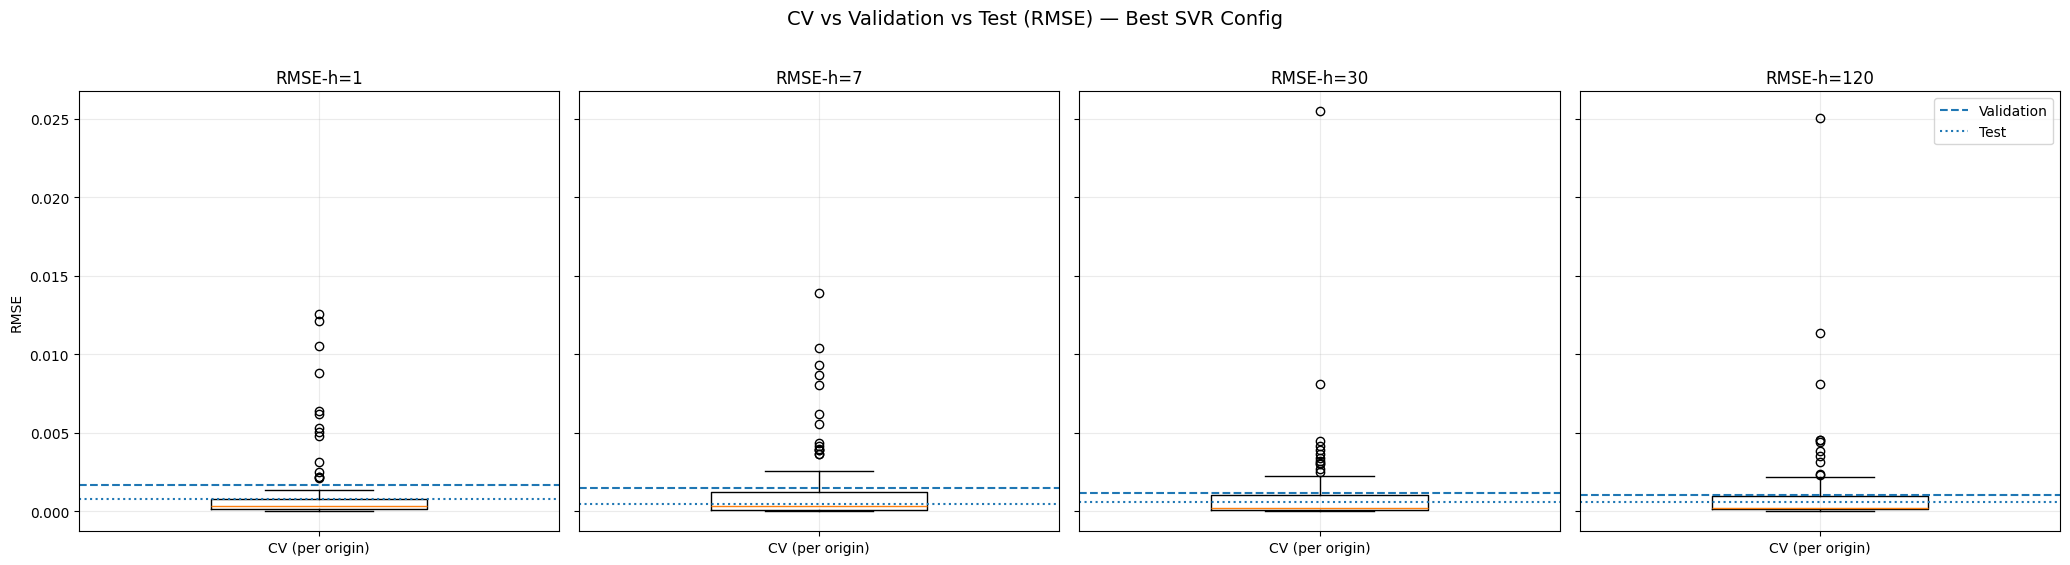

In [41]:
# Boxplots comparing CV distribution (per origin) vs Validation and Test RMSE for the selected best SVR model across multiple horizons.
def plot_svr_cv_val_test_boxplots_multi(results_train_svr: dict, results_validation_svr: dict, results_test_svr: dict, horizons: tuple[int, ...] = (1, 7, 30, 120)):
    """
    Plot CV distribution, validation RMSE and test RMSE for the selected SVR configuration.
    The plot compares per-origin training CV errors against validation and final test errors across multiple horizons.

    Parameters
    ----------
    results_train_svr (dict): Dictionary returned by SVR training CV, containing df_all_train.

    results_validation_svr (dict): Dictionary returned by SVR validation, containing best_config and best_row.

    results_test_svr (dict): Dictionary returned by SVR test evaluation, containing test_results.

    horizons (tuple[int, ...], default=(1, 7, 30, 120)): Forecast horizons to display.

    Returns
    -------
    None: The function displays a matplotlib figure.
    """

    df_all = results_train_svr["df_all_train"].copy()
    best_cfg = results_validation_svr["best_config"]

    # Filter CV rows for the selected best config (SVR)
    mask = (df_all["n_lags"].eq(best_cfg.n_lags)
            & df_all["kernel"].astype(str).eq(str(best_cfg.kernel))
            & np.isclose(df_all["C"].astype(float), float(best_cfg.C))
            & np.isclose(df_all["epsilon"].astype(float), float(best_cfg.epsilon))
            & df_all["gamma"].astype(str).eq(str(best_cfg.gamma))
            & df_all["degree"].astype(int).eq(int(best_cfg.degree))
            & np.isclose(df_all["coef0"].astype(float), float(best_cfg.coef0)))

    df_cv_best = df_all.loc[mask].copy()

    if df_cv_best.empty:
        available = (df_all[["n_lags", "kernel", "C", "epsilon", "gamma", "degree", "coef0"]].drop_duplicates())

        raise ValueError("No CV rows found for best SVR config in df_all_train.\n"
                         f"Best cfg: {best_cfg.to_label()}\n"
                         f"Available configs:\n{available}")

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    # Prepare plot
    fig, axes = plt.subplots(1, len(horizons), figsize=(5.2 * len(horizons), 5.5), sharey=True)

    if len(horizons) == 1:
        axes = [axes]

    for ax, h in zip(axes, horizons):

        col = f"RMSE-h={h}"

        if col not in df_cv_best.columns:
            raise ValueError(f"{col} not found in CV results.")

        if col not in results_validation_svr["best_row"].index:
            raise ValueError(f"{col} not found in validation results.")

        if col not in results_test_svr["test_results"].columns:
            raise ValueError(f"{col} not found in test results.")

        cv_values = df_cv_best[col].dropna().values
        val_value = float(results_validation_svr["best_row"][col])
        test_value = float(results_test_svr["test_results"].iloc[0][col])

        ax.boxplot(cv_values, vert=True, widths=0.45)
        ax.axhline(val_value, linestyle="--", label="Validation")
        ax.axhline(test_value, linestyle=":", label="Test")

        ax.set_title(f"RMSE-h={h}")
        ax.set_xticks([1])
        ax.set_xticklabels(["CV (per origin)"])
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("RMSE")
    axes[-1].legend(loc="upper right")

    fig.suptitle("CV vs Validation vs Test (RMSE) — Best SVR Config", y=1.02, fontsize=14)

    plt.tight_layout()
    plt.show()

plot_svr_cv_val_test_boxplots_multi(results_train_svr=results_train_svr,
                                    results_validation_svr=results_validation_svr,
                                    results_test_svr=results_test_svr,
                                    horizons=(1, 7, 30, 120))

In [42]:
# Calculate generalization gaps in percentage terms for each horizon and the average score.
def svr_generalization_gaps_percent(results_train_svr: dict, results_validation_svr: dict, results_test_svr: dict):
    """
    Calculate percentage generalization gaps between Train CV, Validation and Test for the selected SVR configuration.
    The selected validation configuration is used to compare RMSE degradation or improvement across phases.

    Parameters
    ----------
    results_train_svr (dict): Dictionary returned by SVR training CV, containing summary_train.

    results_validation_svr (dict): Dictionary returned by SVR validation, containing best_config and best_row.

    results_test_svr (dict): Dictionary returned by SVR test evaluation, containing test_results.

    Returns
    -------
    df (pd.DataFrame): DataFrame with percentage gaps for each RMSE horizon and mean RMSE score.
    """

    best_cfg = results_validation_svr["best_config"]
    df_train = results_train_svr["summary_train"].copy()

    mask = (df_train["n_lags"].eq(best_cfg.n_lags)
            & df_train["kernel"].astype(str).eq(str(best_cfg.kernel))
            & np.isclose(df_train["C"].astype(float), float(best_cfg.C))
            & np.isclose(df_train["epsilon"].astype(float), float(best_cfg.epsilon))
            & df_train["gamma"].astype(str).eq(str(best_cfg.gamma))
            & df_train["degree"].astype(int).eq(int(best_cfg.degree))
            & np.isclose(df_train["coef0"].astype(float), float(best_cfg.coef0)))

    df_train_best = df_train.loc[mask]

    if df_train_best.empty:
        available = (df_train[["n_lags", "kernel", "C", "epsilon", "gamma", "degree", "coef0"]].drop_duplicates())

        raise ValueError("Best validation SVR config not found in results_train_svr['summary_train'].\n"
                         f"Best cfg: {best_cfg.to_label()}\n"
                         f"Available configs:\n{available}")

    train_row = df_train_best.iloc[0]
    val_row = results_validation_svr["best_row"]
    test_row = results_test_svr["test_results"].iloc[0]

    rmse_cols = sorted([c for c in test_row.index if str(c).startswith("RMSE-h=")], key=lambda x: int(str(x).split("=")[1]))
    metric_cols = rmse_cols + (["score_rmse_mean"] if "score_rmse_mean" in test_row.index else [])

    def pct_gap(a, b, eps: float = 1e-8):
        b = float(b)

        if abs(b) < eps:
            return np.nan

        return (float(a) - b) / b * 100.0

    rows = []

    for m in metric_cols:
        rows.append({"Metric": m,
                     "Val_vs_Train_%": pct_gap(val_row[m], train_row[m]),
                     "Test_vs_Train_%": pct_gap(test_row[m], train_row[m]),
                     "Test_vs_Val_%": pct_gap(test_row[m], val_row[m])})

    df = pd.DataFrame(rows)
    df = df.set_index("Metric").T

    return df

In [43]:
# Calculate and display SVR generalization gaps in percentage terms
gap_df_svr = svr_generalization_gaps_percent(results_train_svr=results_train_svr,
                                             results_validation_svr=results_validation_svr,
                                             results_test_svr=results_test_svr)

display_table(gap_df_svr, "SVR Generalization Gaps (%)")


SVR Generalization Gaps (%)
╒═════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════════╕
│                 │   RMSE-h=1   │   RMSE-h=7   │  RMSE-h=15   │  RMSE-h=30   │  RMSE-h=120  │   score_rmse_mean │
╞═════════════════╪══════════════╪══════════════╪══════════════╪══════════════╪══════════════╪═══════════════════╡
│ Val_vs_Train_%  │ 24.17350035  │ -4.21118803  │ -66.67854623 │ -3.30512830  │ -21.04027201 │      -29.29657498 │
├─────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────────┤
│ Test_vs_Train_% │ -43.71230907 │ -70.80810923 │ -86.09019698 │ -52.53845130 │ -53.32737276 │      -68.80983214 │
├─────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────────┤
│  Test_vs_Val_%  │ -54.67012626 │ -69.52473867 │ -58.25571382 │ -50.91616767 │ -40.89059268 │      -55.88591663 │
╘═════════════════╧══════════════╧══════════════╧══

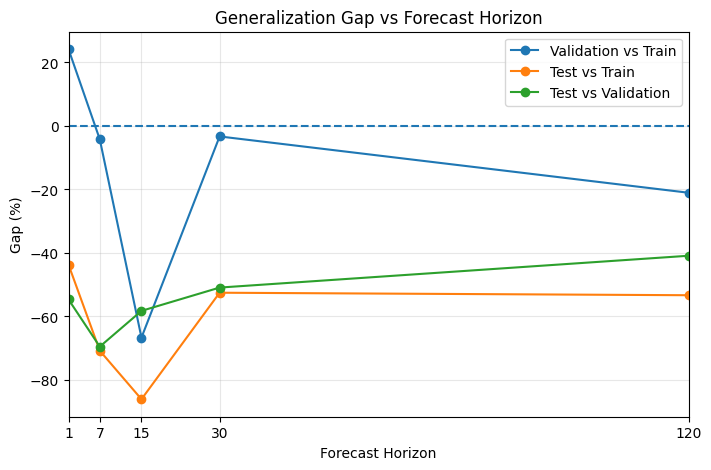

In [44]:
# Plot percentage generalization gaps vs forecast horizon.
df = gap_df_svr.copy()

# Extract horizons from column names
horizons = [int(c.split("=")[1]) for c in df.columns if c.startswith("RMSE-h=")]

# Sort horizons
horizons = sorted(horizons)

val_train = [df.loc["Val_vs_Train_%", f"RMSE-h={h}"] for h in horizons]
test_train = [df.loc["Test_vs_Train_%", f"RMSE-h={h}"] for h in horizons]
test_val = [df.loc["Test_vs_Val_%", f"RMSE-h={h}"] for h in horizons]

plt.figure(figsize=(8,5))

plt.plot(horizons, val_train, marker="o", label="Validation vs Train")
plt.plot(horizons, test_train, marker="o", label="Test vs Train")
plt.plot(horizons, test_val, marker="o", label="Test vs Validation")

plt.axhline(0, linestyle="--")
plt.xticks(horizons)
plt.xlim(min(horizons), max(horizons))

plt.xlabel("Forecast Horizon")
plt.ylabel("Gap (%)")
plt.title("Generalization Gap vs Forecast Horizon")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [45]:
# teste de manwitney

---

# Comparação com o modelo Seasonal Naive

In [46]:
# Naive forecast implementation
def naive_forecast(y_train: pd.Series, h: int):
    """
    Generate a naive persistence forecast using the last available observation.
    The same last observed value is repeated for all forecast horizons.

    Parameters
    ----------
    y_train (pd.Series): Training series available up to the forecast origin.

    h (int): Maximum forecast horizon.

    Returns
    -------
    forecast (np.ndarray): Naive forecasts from horizon 1 to horizon h.
    """

    if not isinstance(y_train, pd.Series):
        raise TypeError("y_train must be a pandas Series.")

    if len(y_train) < 1:
        raise ValueError("Training series must contain at least one observation.")

    if h < 1:
        raise ValueError("Forecast horizon h must be >= 1.")

    last_value = float(y_train.iloc[-1])

    forecast = np.repeat(last_value, h)

    return forecast.astype(float)


# Seasonal naive forecast implementation
def seasonal_naive_forecast(y_train: pd.Series, h: int, m: int):
    """
    Generate a seasonal naive forecast using the most recent seasonal cycle.
    Forecasts are obtained by repeating the last observed seasonal pattern.

    Parameters
    ----------
    y_train (pd.Series): Training series available up to the forecast origin.

    h (int): Maximum forecast horizon.

    m (int): Seasonal period.

    Returns
    -------
    forecast (np.ndarray): Seasonal naive forecasts from horizon 1 to horizon h.
    """

    if not isinstance(y_train, pd.Series):
        raise TypeError("y_train must be a pandas Series.")

    if h < 1:
        raise ValueError("Forecast horizon h must be >= 1.")

    if m is None or m < 2:
        raise ValueError("Seasonal period m must be >= 2 for seasonal naive forecast.")

    if len(y_train) < m:
        raise ValueError("Training series too short for seasonal naive.")

    last_season = y_train.iloc[-m:].values.astype(float)

    reps = int(np.ceil(h / m))
    forecast = np.tile(last_season, reps)[:h]

    return forecast.astype(float)

In [47]:
# Evaluate naive / seasonal naive on a single validation/test origin
def naive_evaluate_single_origin(y_train: pd.Series, y_eval: pd.Series, horizons: tuple[int, ...], m: Optional[int] = None, metric: str = "RMSE",
                                 scale_transformer: Optional[PowerTransformer] = None):
    """
    Evaluate naive or seasonal naive on a single forecast origin.
    The evaluation observations y_eval are used only for error computation.

    Parameters
    ----------
    y_train (pd.Series): Training series available before the forecast origin.

    y_eval (pd.Series): Evaluation series containing future observations after the forecast origin.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    m (int | None, default=None): Seasonal period. If None, the standard naive forecast is used.

    metric (str, default="RMSE"): Metric used to report the selected score. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer used to invert transformed volatility-proxy values.

    Returns
    -------
    row (dict): Dictionary with naive configuration, per-horizon metrics and aggregate scores.

    df_forecasts (pd.DataFrame): DataFrame with forecasts, observed values and residuals by horizon.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_eval) < hmax:
        raise ValueError(f"Evaluation set too short for hmax={hmax}. len(y_eval)={len(y_eval)}")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if m is None:
        y_hat = naive_forecast(y_train=y_train, h=hmax)
        row = {"model": "naive", "variant": "naive", "m": None}

    else:
        y_hat = seasonal_naive_forecast(y_train=y_train, h=hmax, m=m)
        row = {"model": "naive", "variant": f"seasonal_naive(m={m})", "m": m}

    y_hat = np.asarray(y_hat, dtype=float)
    y_eval_hmax = y_eval.iloc[:hmax].values.astype(float)

    # Convert forecasts to original volatility-proxy scale
    y_hat_original = inverse_variance_transformation(values=y_hat,
                                                     reference_series=y_train,
                                                     yeo_johnson_transformer=scale_transformer,
                                                     clip_negative=True)

    # Convert observed future values to original volatility-proxy scale
    y_eval_hmax_original = inverse_variance_transformation(values=y_eval_hmax,
                                                           reference_series=y_eval,
                                                           yeo_johnson_transformer=scale_transformer,
                                                           clip_negative=True)

    rmse_list = []
    mape_list = []
    smape_list = []
    qlike_list = []

    forecast_rows = []

    for h in horizons:

        y_true = np.asarray([y_eval_hmax_original[h - 1]], dtype=float)
        y_pred = np.asarray([y_hat_original[h - 1]], dtype=float)

        row[f"RMSE-h={h}"] = rmse(y_true, y_pred)
        row[f"MAPE-h={h}"], row[f"SMAPE-h={h}"] = mape_smape(y_true, y_pred)
        row[f"QLIKE-h={h}"] = qlike(y_true, y_pred)

        rmse_list.append(row[f"RMSE-h={h}"])
        mape_list.append(row[f"MAPE-h={h}"])
        smape_list.append(row[f"SMAPE-h={h}"])
        qlike_list.append(row[f"QLIKE-h={h}"])

        y_true_h = float(y_eval_hmax_original[h - 1])
        y_pred_h = float(y_hat_original[h - 1])

        forecast_rows.append({"model": "naive",
                              "variant": row["variant"],
                              "m": m,
                              "horizon": int(h),
                              "y_true_vol_proxy": y_true_h,
                              "forecast": y_pred_h,
                              "residual": y_true_h - y_pred_h})

    row["score_rmse_mean"] = float(np.nanmean(rmse_list))
    row["score_mape_mean"] = float(np.nanmean(mape_list))
    row["score_smape_mean"] = float(np.nanmean(smape_list))
    row["score_qlike_mean"] = float(np.nanmean(qlike_list))

    if metric == "RMSE":
        row["score_selected"] = row["score_rmse_mean"]
    elif metric == "MAPE":
        row["score_selected"] = row["score_mape_mean"]
    elif metric == "SMAPE":
        row["score_selected"] = row["score_smape_mean"]
    elif metric == "QLIKE":
        row["score_selected"] = row["score_qlike_mean"]

    row["valid"] = True

    df_forecasts = pd.DataFrame(forecast_rows)

    return row, df_forecasts

In [48]:
# Evaluate naive / seasonal naive using rolling/expanding origins
def naive_evaluate_rolling(y_train: pd.Series, y_eval: pd.Series, horizons: tuple[int, ...], m: Optional[int] = None, metric: str = "RMSE",
                           mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None,
                           scale_transformer: Optional[PowerTransformer] = None, stage_name: str = "evaluation"):
    """
    Evaluate naive or seasonal naive using rolling/expanding origins.

    Parameters
    ----------
    y_train (pd.Series): Historical series before the evaluation period.

    y_eval (pd.Series): Validation or test series.

    horizons (tuple[int, ...]): Forecast horizons to evaluate.

    m (Optional[int]): Seasonal period for seasonal naive. If None, use non-seasonal naive.

    metric (str): Metric to use for scoring and model selection ("RMSE", "MAPE", "SMAPE", "QLIKE").

    mode (BacktestMode): "rolling" or "expanding" origins.

    step (int): Step size for rolling origins.

    window (Optional[int]): Window size for rolling origins.

    scale_transformer (Optional[PowerTransformer]): Transformer for variance stabilization.

    stage_name (str): Name used only for progress display.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    blocks = generate_evaluation_backtest_blocks(y_train=y_train, y_val=y_eval, horizons=horizons, mode=mode, window=window, step=step)

    y_full = pd.concat([y_train, y_eval]).copy()

    rows = []
    forecast_frames = []

    for b in tqdm(blocks, desc=f"Naive {stage_name} - origins", unit="origin"):

        try:
            origin_date = y_full.index[b.origin]
        except Exception:
            origin_date = None

        try:
            out, df_forecast = naive_evaluate_single_origin(y_train=b.train,
                                                            y_eval=b.test,
                                                            horizons=horizons,
                                                            m=m,
                                                            metric=metric,
                                                            scale_transformer=scale_transformer)

            if out.get("valid", False):
                out["origin"] = b.origin
                out["origin_date"] = origin_date
                rows.append(out)

                if not df_forecast.empty:
                    df_forecast["origin"] = b.origin
                    df_forecast["origin_date"] = origin_date
                    forecast_frames.append(df_forecast)

        except Exception as e:
            # Keep robust behaviour, but do not stop the full evaluation
            # print(f"Naive failed at origin {b.origin}: {e}")
            continue

    df_by_origin = pd.DataFrame(rows)

    df_forecasts = (pd.concat(forecast_frames, ignore_index=True) if len(forecast_frames) else pd.DataFrame())

    if df_by_origin.empty:
        raise ValueError("No valid naive origins could be evaluated.")

    group_cols = ["model", "variant", "m"]

    rmse_cols = sorted([c for c in df_by_origin.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
    mape_cols = sorted([c for c in df_by_origin.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
    smape_cols = sorted([c for c in df_by_origin.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
    qlike_cols = sorted([c for c in df_by_origin.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

    metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + ["score_rmse_mean",
                                                                      "score_mape_mean",
                                                                      "score_smape_mean",
                                                                      "score_qlike_mean",
                                                                      "score_selected"])

    metric_cols = [c for c in metric_cols if c in df_by_origin.columns]

    df_results = (df_by_origin.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

    id_cols = ["model", "variant", "m"]
    score_cols = ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"]

    ordered_cols = id_cols + rmse_cols + mape_cols + smape_cols + qlike_cols + score_cols
    ordered_cols = [c for c in ordered_cols if c in df_results.columns]

    df_results = df_results[ordered_cols].copy()

    return {"results": df_results,
            "results_by_origin": df_by_origin,
            "df_forecasts": df_forecasts,
            "blocks_n": len(blocks),
            "hmax": max(horizons),
            "model": "naive",
            "variant": "naive" if m is None else f"seasonal_naive(m={m})",
            "m": m}

In [49]:
# Caching mechanism for Naive rolling/expanding test results
def run_or_load_naive_test(cache_dir: str, cache_name: str, y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, horizons: tuple[int, ...], m: Optional[int] = None,
                           metric: str = "RMSE", mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None,
                           scale_transformer: Optional[PowerTransformer] = None):
    """
    Run or load final Naive test evaluation using rolling/expanding test origins.
    The test set y_test is used only for final out-of-sample evaluation.

    Parameters
    ----------
    cache_dir (str): Directory where test results are stored.

    cache_name (str): Cache folder name for the current Naive test run.

    y_train (pd.Series): Training series.

    y_val (pd.Series): Validation series used before the final test period.

    y_test (pd.Series): Test series used only for final out-of-sample evaluation.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    m (int | None, default=None): Seasonal period. If None, the standard naive forecast is used.

    metric (str, default="RMSE"): Metric used to report the selected score. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate test origins.

    step (int, default=1): Step between test origins.

    window (int | None, default=None): Rolling window size. If None, uses len(y_train) + len(y_val).

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer used to invert transformed volatility-proxy values.

    Returns
    -------
    out (dict): Dictionary with final Naive test results, per-origin test results, forecasts and cache metadata.
    """

    def series_signature(y: pd.Series):
        """
        Create a simple signature for a Series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    test_file = cache_path / "test_results.parquet"
    test_by_origin_file = cache_path / "test_results_by_origin.parquet"
    forecasts_file = cache_path / "forecasts.parquet"

    expected_meta = {"horizons": list(sorted(set(int(h) for h in horizons))),
                     "mode": mode,
                     "step": step,
                     "window": int(window) if window is not None else None,
                     "m": int(m) if m is not None else None,
                     "metric": metric,
                     "model": "naive",
                     "variant": "naive" if m is None else f"seasonal_naive(m={m})",
                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy",
                     "test_type": "rolling_expanding_origins",
                     "y_train_signature": series_signature(y_train),
                     "y_train_length": len(y_train),
                     "y_train_start": str(y_train.index.min()),
                     "y_train_end": str(y_train.index.max()),
                     "y_val_signature": series_signature(y_val),
                     "y_val_length": len(y_val),
                     "y_val_start": str(y_val.index.min()),
                     "y_val_end": str(y_val.index.max()),
                     "y_test_signature": series_signature(y_test),
                     "y_test_length": len(y_test),
                     "y_test_start": str(y_test.index.min()),
                     "y_test_end": str(y_test.index.max())}

    required_files_exist = (meta_file.exists() and test_file.exists() and test_by_origin_file.exists() and forecasts_file.exists())

    # Load only if cache exists and metadata matches current input
    if required_files_exist:
        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        cache_is_valid = (meta.get("horizons") == expected_meta["horizons"]
                          and meta.get("mode") == expected_meta["mode"]
                          and meta.get("step") == expected_meta["step"]
                          and meta.get("window") == expected_meta["window"]
                          and meta.get("m") == expected_meta["m"]
                          and meta.get("metric") == expected_meta["metric"]
                          and meta.get("model") == expected_meta["model"]
                          and meta.get("variant") == expected_meta["variant"]
                          and meta.get("stored_forecasts") == expected_meta["stored_forecasts"]
                          and meta.get("forecast_scale") == expected_meta["forecast_scale"]
                          and meta.get("test_type") == expected_meta["test_type"]
                          and meta.get("y_train_signature") == expected_meta["y_train_signature"]
                          and meta.get("y_train_length") == expected_meta["y_train_length"]
                          and meta.get("y_train_start") == expected_meta["y_train_start"]
                          and meta.get("y_train_end") == expected_meta["y_train_end"]
                          and meta.get("y_val_signature") == expected_meta["y_val_signature"]
                          and meta.get("y_val_length") == expected_meta["y_val_length"]
                          and meta.get("y_val_start") == expected_meta["y_val_start"]
                          and meta.get("y_val_end") == expected_meta["y_val_end"]
                          and meta.get("y_test_signature") == expected_meta["y_test_signature"]
                          and meta.get("y_test_length") == expected_meta["y_test_length"]
                          and meta.get("y_test_start") == expected_meta["y_test_start"]
                          and meta.get("y_test_end") == expected_meta["y_test_end"])

        if cache_is_valid:
            df_test = pd.read_parquet(test_file)
            df_test_by_origin = pd.read_parquet(test_by_origin_file)
            df_forecasts_test = pd.read_parquet(forecasts_file)

            return {"results": df_test,
                    "results_by_origin": df_test_by_origin,
                    "df_forecasts": df_forecasts_test,
                    "blocks_n": meta.get("blocks_n"),
                    "hmax": meta.get("hmax"),
                    "model": "naive",
                    "variant": expected_meta["variant"],
                    "m": m,
                    "forecast": df_forecasts_test["forecast"].to_numpy(dtype=float) if "forecast" in df_forecasts_test.columns else np.array([]),
                    "y_true": df_forecasts_test["y_true_vol_proxy"].to_numpy(dtype=float) if "y_true_vol_proxy" in df_forecasts_test.columns else np.array([]),
                    "meta": meta}

        print("Warning: cache metadata does not match current Naive test input. Recomputing Naive test.")

    # Otherwise run rolling/expanding test evaluation
    y_dev = pd.concat([y_train, y_val]).copy()

    out = naive_evaluate_rolling(y_train=y_dev,
                                 y_eval=y_test,
                                 horizons=horizons,
                                 m=m,
                                 metric=metric,
                                 mode=mode,
                                 step=step,
                                 window=window,
                                 scale_transformer=scale_transformer,
                                 stage_name="test")

    meta = {**expected_meta,
            "hmax": int(out.get("hmax", max(horizons))),
            "y_dev_len": int(len(y_dev)),
            "blocks_n": int(out.get("blocks_n", 0))}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["results"].to_parquet(test_file, index=False)
    out["results_by_origin"].to_parquet(test_by_origin_file, index=False)
    out["df_forecasts"].to_parquet(forecasts_file, index=False)

    out["meta"] = meta

    return out

In [50]:
# Evaluate naive benchmark on test set using rolling/expanding origins
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_SVR_results"
cache_name_naive_test = (f"Tese_Bitcoin_Naive_test_{mode}_step{step}_h{max(horizons)}_pkl")

results_naive_test_svr = run_or_load_naive_test(cache_dir=cache_dir,
                                                cache_name=cache_name_naive_test,
                                                y_train=y_train,
                                                y_val=y_val,
                                                y_test=y_test,
                                                horizons=horizons,
                                                m=None,
                                                metric="RMSE",
                                                mode=mode,
                                                step=step,
                                                window=None,
                                                scale_transformer=scale_transformer)

df_naive_test_svr = results_naive_test_svr["results"].copy()

display_table(df_naive_test_svr, "Naive model (rolling test):")

Naive test - origins: 100%|██████████| 68/68 [00:00<00:00, 386.21origin/s]



Naive model (rolling test):
╒════╤═════════╤═══════════╤═════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═════════════════╤══════════════════╤════════════════╤═══════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  model  │  variant  │  m  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1     │     MAPE-h=7     │   MAPE-h=15    │   MAPE-h=30   │   MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1   │  QLIKE-h=7   │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mean  │   score_selected │
╞════╪═════════╪═══════════╪═════╪════════════╪════════════╪═════════════╪═════════

In [51]:
# Compare SVR vs Naive on test set
df_svr_test = results_test_svr["test_results"].copy()

# Use the rolling/expanding naive test results
df_naive_results = results_naive_test_svr["results"].copy()

# Add model identifiers before concatenating
df_svr_test["Model"] = "SVR"
df_naive_results["Model"] = "Naive"

# Concatenate results
df_compare_svr = pd.concat([df_svr_test, df_naive_results], ignore_index=True)

# Set model name as index
df_compare_svr = df_compare_svr.set_index("Model")

# Remove columns that are not useful for final presentation
cols_to_drop = ["model", "variant", "m", "score_selected"]
df_compare_svr = df_compare_svr.drop(columns=cols_to_drop, errors="ignore")

# Convert SVR orders to integer display where possible
for col in ["p", "d", "q"]:
    if col in df_compare_svr.columns:
        df_compare_svr[col] = df_compare_svr[col].astype("Int64")

# Optional: replace missing SVR-specific parameters in Naive row with "-"
for col in ["p", "d", "q", "trend"]:
    if col in df_compare_svr.columns:
        df_compare_svr[col] = df_compare_svr[col].astype(str).replace("<NA>", "-").replace("nan", "-")

display_table(df_compare_svr, "SVR vs Naive (test)")


SVR vs Naive (test)
╒═════════╤═════════════╤══════════╤════════════╤════════════╤═════════╤════════════╤════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═════════════════╤══════════════════╤════════════════╤═══════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╕
│  Model  │   n_lags    │  kernel  │     C      │  epsilon   │  gamma  │   degree   │   coef0    │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1     │     MAPE-h=7     │   MAPE-h=15    │   MAPE-h=30   │   MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1   │  QLIKE-h=7   │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │   score_qlike_mean │
╞

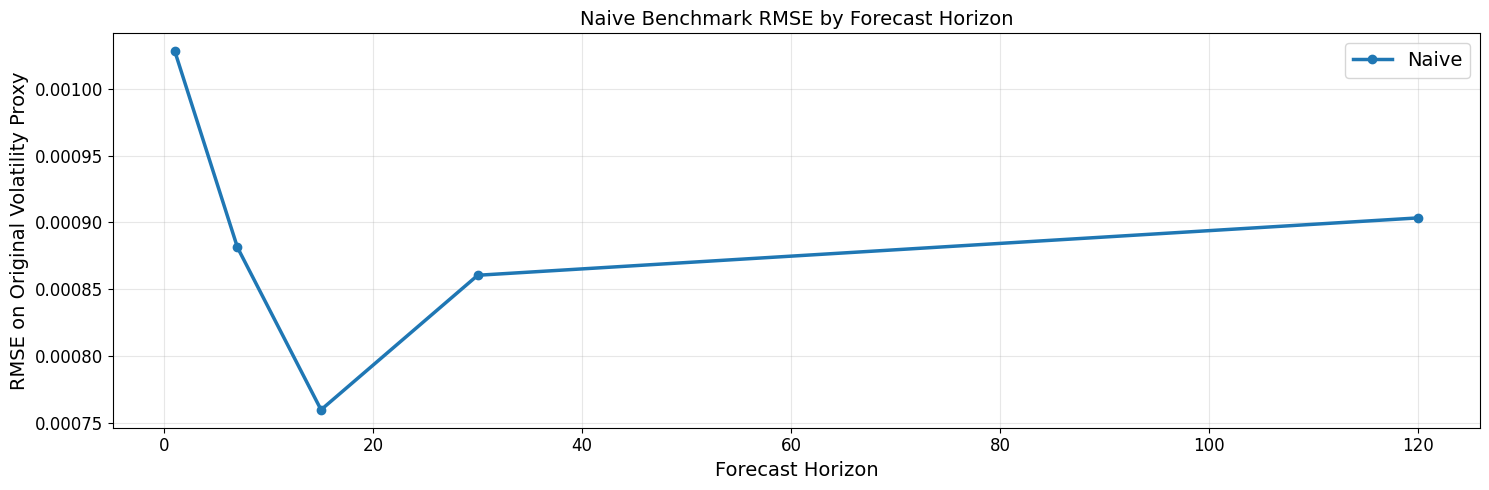

In [52]:
# Plot Naive benchmark RMSE across forecast horizons
def plot_naive_rmse_vs_horizon(df_naive: pd.DataFrame):
    """
    Plot Naive benchmark RMSE across forecast horizons.
    The RMSE values are assumed to be computed on the original volatility-proxy scale.

    Parameters
    ----------
    df_naive (pd.DataFrame): DataFrame containing Naive benchmark results with RMSE columns by horizon.

    Returns
    -------
    None: The function displays a matplotlib figure.
    """

    if df_naive is None or not isinstance(df_naive, pd.DataFrame) or df_naive.empty:
        raise ValueError("df_naive must be a non-empty DataFrame.")

    # Identify RMSE columns
    rmse_cols = sorted([c for c in df_naive.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))

    if len(rmse_cols) == 0:
        raise ValueError("No RMSE horizon columns were found in df_naive.")

    horizons = [int(c.split("=")[1]) for c in rmse_cols]

    # Select Naive row
    if "model" in df_naive.columns:
        naive_rows = df_naive[df_naive["model"].astype(str).str.lower().eq("naive")]

        if naive_rows.empty:
            raise ValueError("No row with model='naive' was found in df_naive.")

        naive_row = naive_rows.iloc[0]

    else:
        naive_row = df_naive.iloc[0]

    naive_rmse = naive_row[rmse_cols].astype(float).values

    plt.figure(figsize=(15, 5))

    plt.plot(horizons, naive_rmse, marker="o", linewidth=2.5, label="Naive")

    plt.title("Naive Benchmark RMSE by Forecast Horizon", fontsize=14)
    plt.xlabel("Forecast Horizon", fontsize=14)
    plt.xticks(fontsize=12)
    plt.ylabel("RMSE on Original Volatility Proxy", fontsize=14)
    plt.yticks(fontsize=12)

    plt.legend(fontsize=14)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_naive_rmse_vs_horizon(results_naive_test_svr["results"])

---

# Análise de Resíduos

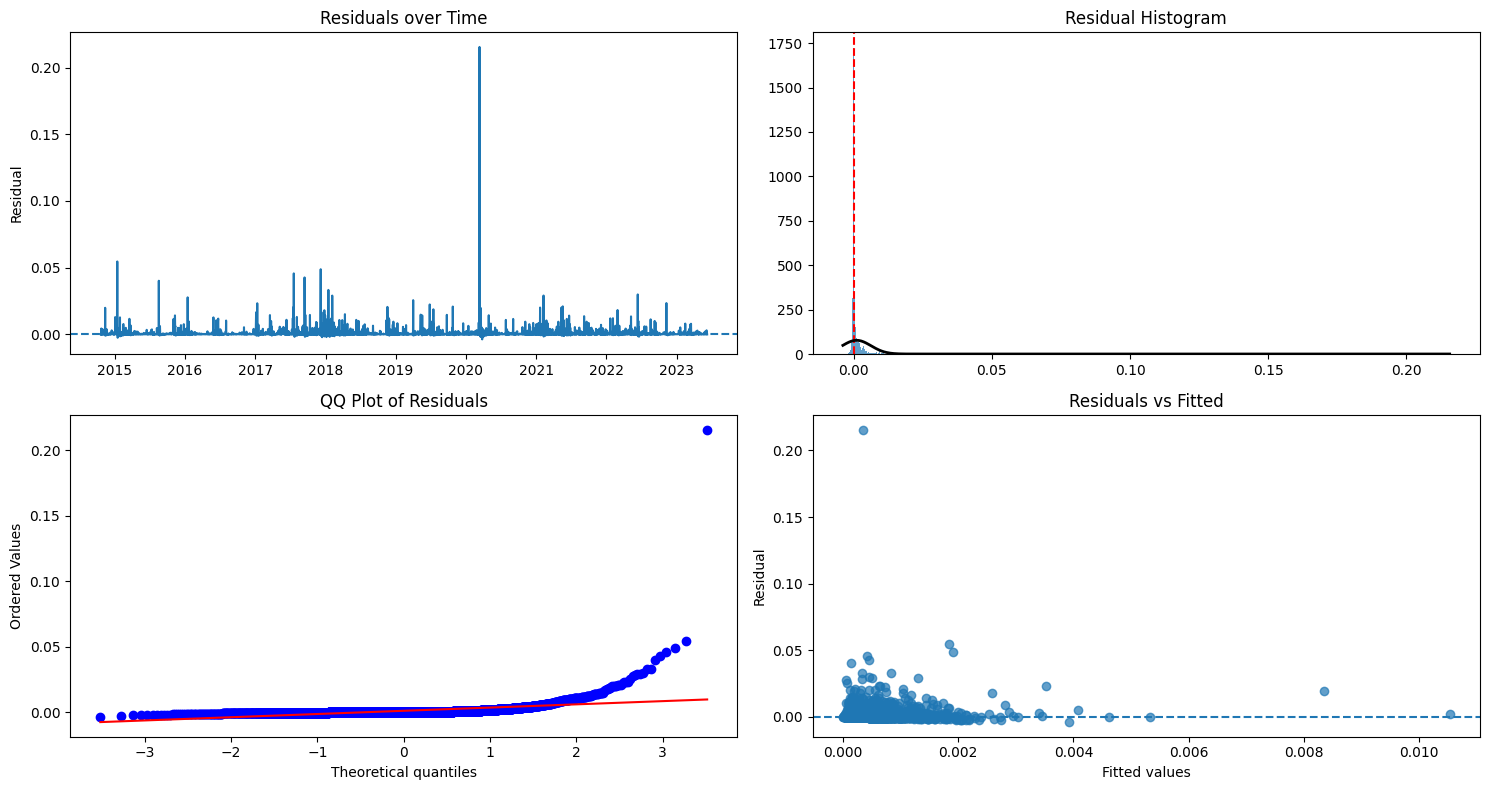

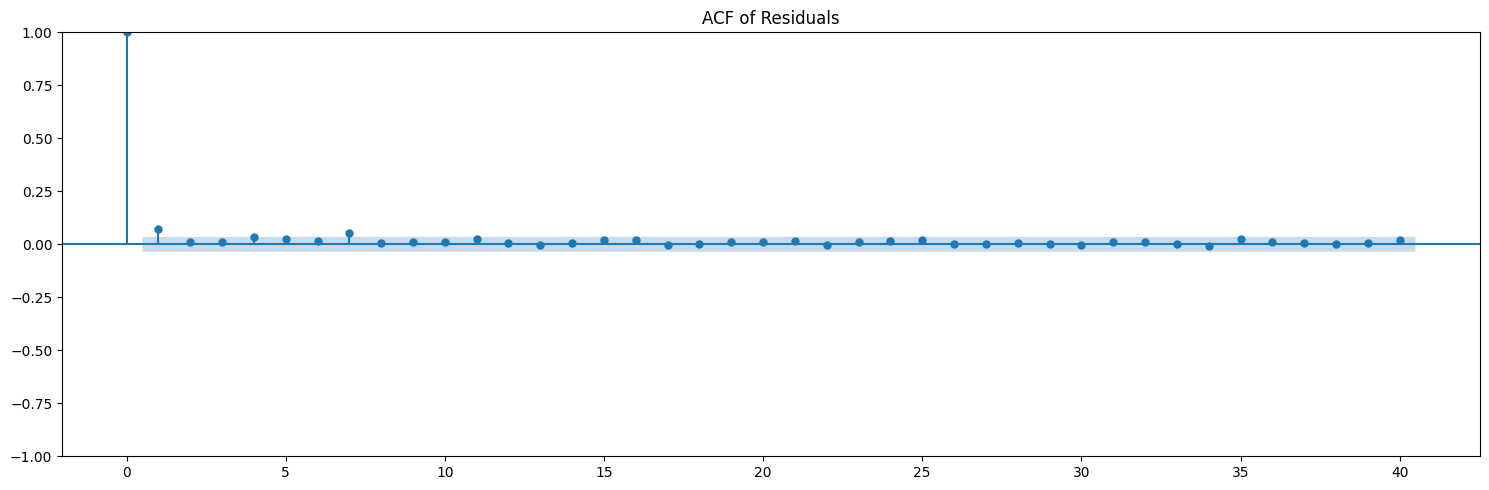


Residual Diagnostics - Final SVR Model - Original Scale
╒════╤════════════════════════════╤══════════════╕
│    │           Metric           │        Value │
╞════╪════════════════════════════╪══════════════╡
│ 0  │            Mean            │   0.00107413 │
├────┼────────────────────────────┼──────────────┤
│ 1  │           Median           │  -0.00001741 │
├────┼────────────────────────────┼──────────────┤
│ 2  │            Std             │   0.00517442 │
├────┼────────────────────────────┼──────────────┤
│ 3  │          Skewness          │  24.63902160 │
├────┼────────────────────────────┼──────────────┤
│ 4  │          Kurtosis          │ 949.38623384 │
├────┼────────────────────────────┼──────────────┤
│ 5  │        KS Statistic        │   0.33378254 │
├────┼────────────────────────────┼──────────────┤
│ 6  │         KS p-value         │   0.00000000 │
├────┼────────────────────────────┼──────────────┤
│ 7  │ Ljung-Box p-value (lag=20) │   0.00799825 │
╘════╧═══════════════════

In [53]:
# Final SVR model fitting and residual diagnostics
def fit_final_svr_model(y_train: pd.Series, y_val: pd.Series, cfg: SVRConfig, scaler_type: str = "standard", min_samples: int = 30,
                        scale_transformer: Optional[PowerTransformer] = None, residual_scale: str = "original"):
    """
    Fit the final SVR model on the development set and compute one-step-ahead fitted values and residuals.
    The development set is defined as y_train plus y_val.

    Parameters
    ----------
    y_train (pd.Series): Training series.

    y_val (pd.Series): Validation series used during model selection.

    cfg (SVRConfig): Best SVR configuration selected from validation.

    scaler_type (str, default="minmax"): Scaling method used before fitting the SVR model.

    min_samples (int, default=30): Minimum number of supervised samples required.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer used to invert transformed volatility-proxy values.

    residual_scale (str, default="original"): Scale used for residual computation. Supported values are "original" and "model".

    Returns
    -------
    out (dict): Dictionary with development series, fitted model, fitted values, residuals and residual scale.
    """

    if residual_scale not in ("original", "model"):
        raise ValueError("residual_scale must be either 'original' or 'model'.")

    y_dev = pd.concat([y_train, y_val]).copy()

    h = 1

    if not svr_config_compatible(y=y_dev, cfg=cfg, hmax=h, min_samples=min_samples):
        raise ValueError(f"Selected SVR config is not compatible with y_dev: {cfg.to_label()}")

    if scaler_type == "standard":
        scaler = StandardScaler()

    elif scaler_type == "minmax":
        scaler = MinMaxScaler()

    else:
        raise ValueError("scaler_type must be either 'standard' or 'minmax'.")

    y_dev_values = y_dev.to_numpy(dtype=float).reshape(-1, 1)

    if not np.all(np.isfinite(y_dev_values)):
        raise ValueError("y_dev contains NaN or infinite values.")

    scaler.fit(y_dev_values)

    y_dev_scaled = pd.Series(scaler.transform(y_dev_values).flatten(), index=y_dev.index, name=y_dev.name)

    # One-step-ahead supervised dataset
    x_dev, y_targets, _ = make_svr_features(y=y_dev_scaled, n_lags=cfg.n_lags, horizons=(1,))

    target_col = "target_h=1"

    model = build_svr_model(cfg)

    model.fit(x_dev, y_targets[target_col].to_numpy(dtype=float))

    fitted_model_scale_values = model.predict(x_dev)

    fitted_model_scale = pd.Series(fitted_model_scale_values, index=x_dev.index, name="fitted_model_scale")

    observed_model_scale = y_targets[target_col].copy()
    observed_model_scale.name = "observed_model_scale"

    residuals_model_scale = pd.Series(observed_model_scale.values - fitted_model_scale.values,
                                      index=fitted_model_scale.index,
                                      name="residuals_model_scale")

    y_dev_used = y_dev.loc[fitted_model_scale.index].copy()

    if residual_scale == "model":

        fitted_values = fitted_model_scale.rename("fitted")
        residuals = residuals_model_scale.rename("residuals")

    else:

        # Convert observed development targets to original volatility-proxy scale
        observed_original_values = inverse_variance_transformation(values=y_dev_used.values.astype(float),
                                                                   reference_series=y_dev,
                                                                   yeo_johnson_transformer=scale_transformer,
                                                                   clip_negative=True)

        observed_original = pd.Series(observed_original_values,
                                      index=y_dev_used.index,
                                      name="observed_original_scale")

        # Convert fitted values to original volatility-proxy scale
        fitted_original_values = scaler.inverse_transform(fitted_model_scale.values.reshape(-1, 1)).flatten()

        fitted_original_values = inverse_variance_transformation(values=fitted_original_values,
                                                                 reference_series=y_dev,
                                                                 yeo_johnson_transformer=scale_transformer,
                                                                 clip_negative=True)

        fitted_values = pd.Series(fitted_original_values,
                                  index=fitted_model_scale.index,
                                  name="fitted")

        residuals = pd.Series(observed_original.loc[fitted_values.index].values - fitted_values.values,
                              index=fitted_values.index,
                              name="residuals")

    return {"y_dev": y_dev,
            "y_dev_used": y_dev_used,
            "model": model,
            "scaler": scaler,
            "fitted_values": fitted_values,
            "residuals": residuals,
            "residual_scale": residual_scale}

# Residual diagnostics helper functions
def residual_diagnostics_table(residuals: pd.Series, ljung_box_lags: int = 20):
    """
    Compute a compact residual diagnostics table.
    The residual series is used to assess distributional properties and remaining autocorrelation.

    Parameters
    ----------
    residuals (pd.Series): Residual series.

    ljung_box_lags (int, default=20): Number of lags used in the Ljung-Box test.

    Returns
    -------
    out (pd.DataFrame): DataFrame with residual summary statistics and diagnostic test results.
    """

    residuals = residuals.dropna().copy()

    if residuals.empty:
        raise ValueError("residuals cannot be empty after dropping NaN values.")

    if len(residuals) <= ljung_box_lags:
        raise ValueError(f"Not enough residual observations for Ljung-Box lag={ljung_box_lags}. Got {len(residuals)} observations.")

    lb = acorr_ljungbox(residuals, lags=[ljung_box_lags], return_df=True)

    residual_std = float(residuals.std(ddof=0))

    if residual_std <= 0 or not np.isfinite(residual_std):
        ks_stat = np.nan
        ks_pvalue = np.nan
    else:
        ks_stat, ks_pvalue = kstest(residuals.values, "norm", args=(float(residuals.mean()), residual_std))

    out = pd.DataFrame({"Metric": ["Mean",
                                   "Median",
                                   "Std",
                                   "Skewness",
                                   "Kurtosis",
                                   "KS Statistic",
                                   "KS p-value",
                                   f"Ljung-Box p-value (lag={ljung_box_lags})"],

                        "Value": [float(residuals.mean()),
                                  float(residuals.median()),
                                  float(residuals.std()),
                                  float(residuals.skew()),
                                  float(residuals.kurtosis()),
                                  float(ks_stat),
                                  float(ks_pvalue),
                                  float(lb["lb_pvalue"].iloc[0])]})

    return out


def plot_residual_diagnostics(residuals: pd.Series, fitted_values: pd.Series, acf_lags: int = 40):
    """
    Plot residual diagnostics for the final model.
    The function displays residual time evolution, histogram, QQ plot, residuals versus fitted values and residual autocorrelation.

    Parameters
    ----------
    residuals (pd.Series): Residual series.

    fitted_values (pd.Series): Fitted values aligned with the residual series.

    acf_lags (int, default=40): Number of lags used in the residual ACF plot.

    Returns
    -------
    None: The function displays matplotlib figures.
    """

    residuals = residuals.dropna().copy()

    if residuals.empty:
        raise ValueError("residuals cannot be empty after dropping NaN values.")

    fitted_values = fitted_values.loc[residuals.index].copy()

    fig, axes = plt.subplots(2, 2, figsize=(15, 8))

    # Residual time plot
    axes[0, 0].plot(residuals.index, residuals.values)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Residuals over Time")
    axes[0, 0].set_ylabel("Residual")

    # Histogram with Freedman-Diaconis bins
    n_bins, _ = freedman_diaconis_bins(residuals.values)

    axes[0, 1].hist(residuals.values, bins=n_bins, density=True, alpha=0.7)

    axes[0, 1].axvline(0, linestyle="--", color="red")

    residual_std = float(residuals.std(ddof=0))

    if residual_std > 0 and np.isfinite(residual_std):
        x = np.linspace(residuals.min(), residuals.max(), 500)
        axes[0, 1].plot(x, norm.pdf(x, residuals.mean(), residual_std), linewidth=2, color="black")

    axes[0, 1].set_title("Residual Histogram")

    # QQ plot
    stats.probplot(residuals.values, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title("QQ Plot of Residuals")

    # Residuals vs fitted
    axes[1, 1].scatter(fitted_values.values, residuals.values, alpha=0.7)

    axes[1, 1].axhline(0, linestyle="--")
    axes[1, 1].set_title("Residuals vs Fitted")
    axes[1, 1].set_xlabel("Fitted values")
    axes[1, 1].set_ylabel("Residual")

    plt.tight_layout()
    plt.show()

    # ACF plot in a separate figure
    max_acf_lags = min(acf_lags, len(residuals) - 1)

    if max_acf_lags >= 1:
        fig, ax = plt.subplots(figsize=(15, 5))
        plot_acf(residuals, lags=max_acf_lags, ax=ax)
        ax.set_title("ACF of Residuals")
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough residual observations to plot ACF.")


def run_final_svr_residual_diagnostics(y_train: pd.Series, y_val: pd.Series, cfg: SVRConfig, scaler_type: str = "standard", min_samples: int = 30, ljung_box_lags: int = 20,
                                       acf_lags: int = 40, scale_transformer: Optional[PowerTransformer] = None, residual_scale: str = "original"):
    """
    Run the full residual diagnostics workflow for the final SVR model.
    The model is fitted on the development set and one-step-ahead residual diagnostics are computed on the selected residual scale.

    Parameters
    ----------
    y_train (pd.Series): Training series.

    y_val (pd.Series): Validation series used during model selection.

    cfg (SVRConfig): Best SVR configuration selected from validation.

    scaler_type (str, default="minmax"): Scaling method used before fitting the SVR model.

    min_samples (int, default=30): Minimum number of supervised samples required.

    ljung_box_lags (int, default=20): Number of lags used in the Ljung-Box test.

    acf_lags (int, default=40): Number of lags used in the residual ACF plot.

    scale_transformer (PowerTransformer | None, default=None): Fitted Yeo-Johnson transformer used to invert transformed volatility-proxy values.

    residual_scale (str, default="original"): Scale used for residual computation. Supported values are "original" and "model".

    Returns
    -------
    out (dict): Dictionary with fitted model outputs, residuals, residual scale and diagnostics table.
    """

    fit_pack = fit_final_svr_model(y_train=y_train,
                                   y_val=y_val,
                                   cfg=cfg,
                                   scaler_type=scaler_type,
                                   min_samples=min_samples,
                                   scale_transformer=scale_transformer,
                                   residual_scale=residual_scale)

    diag_table = residual_diagnostics_table(residuals=fit_pack["residuals"], ljung_box_lags=ljung_box_lags)

    plot_residual_diagnostics(residuals=fit_pack["residuals"], fitted_values=fit_pack["fitted_values"], acf_lags=acf_lags)

    return {"y_dev": fit_pack["y_dev"],
            "y_dev_used": fit_pack["y_dev_used"],
            "model": fit_pack["model"],
            "scaler": fit_pack["scaler"],
            "fitted_values": fit_pack["fitted_values"],
            "residuals": fit_pack["residuals"],
            "residual_scale": fit_pack["residual_scale"],
            "diagnostics_table": diag_table}

best_cfg_svr = results_validation_svr["best_config"]

residual_pack_svr = run_final_svr_residual_diagnostics(y_train=y_train,
                                                       y_val=y_val,
                                                       cfg=best_cfg_svr,
                                                       scaler_type="standard",
                                                       min_samples=30,
                                                       ljung_box_lags=20,
                                                       acf_lags=40,
                                                       scale_transformer=scale_transformer,
                                                       residual_scale="original")

display_table(residual_pack_svr["diagnostics_table"], "Residual Diagnostics - Final SVR Model - Original Scale")

---

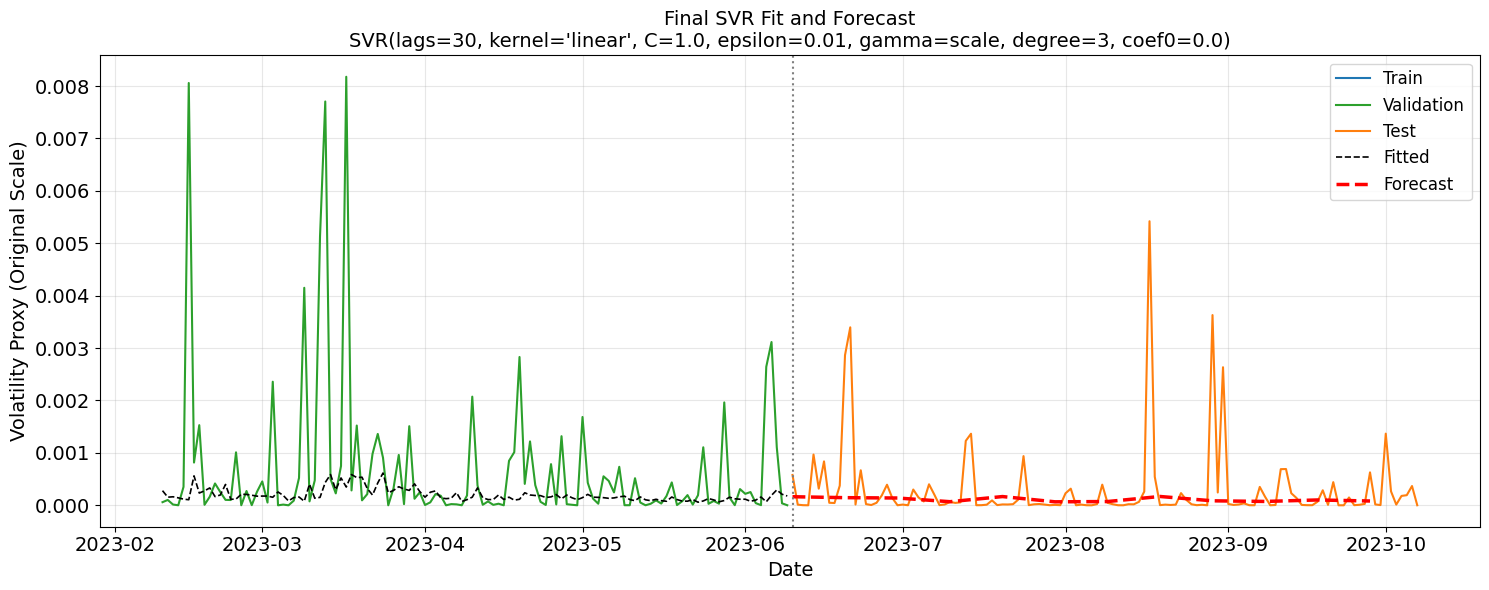

In [54]:
# Final SVR fitted values and stored rolling forecast vs observed test values
window = 120
h_plot = 1 

# Development sample
y_dev = pd.concat([y_train, y_val]).copy()
y_full = pd.concat([y_dev, y_test]).copy()

# Fitted values already computed from final SVR residual diagnostics
fitted_original = residual_pack_svr["fitted_values"].copy()
fitted_original.name = "Fitted"

# Stored test forecasts from rolling/expanding test evaluation
df_forecasts_test_svr = results_test_svr["df_forecasts_test"].copy()

if df_forecasts_test_svr.empty:
    raise ValueError("results_test_svr['df_forecasts_test'] is empty. Check the test evaluation output.")

required_cols = ["origin", "origin_date", "horizon", "y_true_vol_proxy", "forecast", "residual"]
missing_cols = [c for c in required_cols if c not in df_forecasts_test_svr.columns]

if len(missing_cols) > 0:
    raise ValueError(f"df_forecasts_test_svr is missing required columns: {missing_cols}")

# Select forecast horizon
df_h = (df_forecasts_test_svr.loc[df_forecasts_test_svr["horizon"].eq(h_plot)].copy())

if df_h.empty:
    raise ValueError(f"No stored SVR forecasts found for horizon h={h_plot}.")

# Recover actual target date of each stored forecast
target_positions = (df_h["origin"].astype(int).values + df_h["horizon"].astype(int).values - 1)

valid_mask = (target_positions >= 0) & (target_positions < len(y_full))

df_h = df_h.loc[valid_mask].copy()
target_positions = target_positions[valid_mask]

df_h["target_date"] = y_full.index[target_positions]
df_h = df_h.sort_values("target_date").reset_index(drop=True)

# Limit plotting window
y_dev_plot = y_dev.iloc[-window:].copy()

y_train_plot = y_train.loc[y_dev_plot.index.intersection(y_train.index)]
y_val_plot = y_val.loc[y_dev_plot.index.intersection(y_val.index)]

y_test_plot = y_test.iloc[:window].copy()

# Convert observed train/validation/test series to original volatility-proxy scale
y_train_plot_original = pd.Series(inverse_variance_transformation(values=y_train_plot.values.astype(float),
                                                                  reference_series=y_train,
                                                                  yeo_johnson_transformer=scale_transformer,
                                                                  clip_negative=True), index=y_train_plot.index, name="Train")

y_val_plot_original = pd.Series(inverse_variance_transformation(values=y_val_plot.values.astype(float),
                                                                reference_series=y_val,
                                                                yeo_johnson_transformer=scale_transformer,
                                                                clip_negative=True), index=y_val_plot.index, name="Validation")

y_test_plot_original = pd.Series(inverse_variance_transformation(values=y_test_plot.values.astype(float),
                                                                 reference_series=y_test,
                                                                 yeo_johnson_transformer=scale_transformer,
                                                                 clip_negative=True), index=y_test_plot.index, name="Test")

# Select fitted values within the plotted development window
fitted_plot_original = fitted_original.loc[fitted_original.index.intersection(y_dev_plot.index)].copy()

# Select forecasts within the plotted test window
df_h_plot = df_h[df_h["target_date"].isin(y_test_plot_original.index)].copy()

forecast_plot_original = pd.Series(df_h_plot["forecast"].values.astype(float), index=df_h_plot["target_date"], name="Forecast")

plt.figure(figsize=(15, 6))

# Train
plt.plot(y_train_plot_original.index, y_train_plot_original.values, color="tab:blue", label="Train")

# Validation
plt.plot(y_val_plot_original.index, y_val_plot_original.values, color="tab:green", label="Validation")

# Test
plt.plot(y_test_plot_original.index, y_test_plot_original.values, color="tab:orange", label="Test")

# Fitted
plt.plot(fitted_plot_original.index, fitted_plot_original.values, linestyle="--", linewidth=1.2, color="black", label="Fitted")

# Forecast
plt.plot(forecast_plot_original.index, forecast_plot_original.values, linestyle="--", linewidth=2.5, color="red", label="Forecast")

# Split line
plt.axvline(y_test.index[0], linestyle=":", linewidth=1.5, color="grey")

plt.title(f"Final SVR Fit and Forecast\n{results_test_svr['config'].to_label()}", fontsize=14)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Volatility Proxy (Original Scale)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

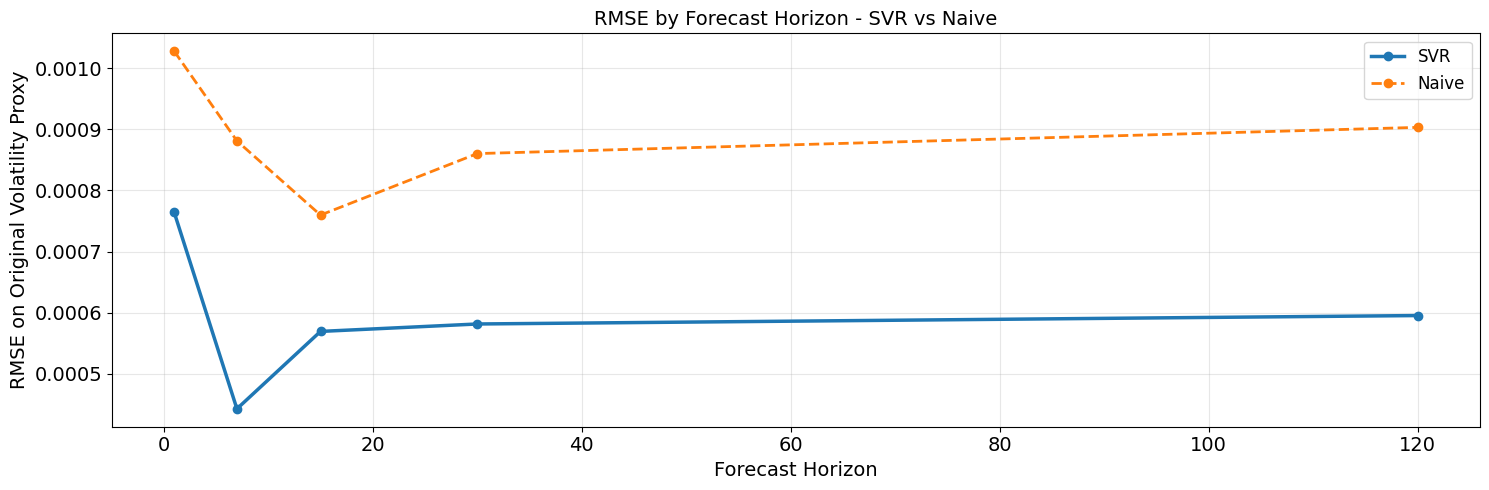

In [55]:
# Compare SVR vs Naive on test set across horizons
def plot_svr_vs_naive_rmse_by_horizon(df_compare: pd.DataFrame):
    """
    Plot RMSE by forecast horizon comparing SVR and Naive.
    The RMSE values are assumed to be computed on the original volatility-proxy scale.

    Parameters
    ----------
    df_compare (pd.DataFrame): DataFrame containing SVR and Naive test results indexed by model name.

    Returns
    -------
    None: The function displays a matplotlib figure.
    """

    # Ensure index is clean
    df_compare = df_compare.copy()
    df_compare.index = df_compare.index.astype(str).str.strip()

    # Identify RMSE columns
    rmse_cols = sorted([c for c in df_compare.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))

    if len(rmse_cols) == 0:
        raise ValueError("No RMSE-h= columns found in df_compare.")

    if "SVR" not in df_compare.index:
        raise ValueError(f"'SVR' not found in df_compare index. Available index values: {list(df_compare.index)}")

    if "Naive" not in df_compare.index:
        raise ValueError(f"'Naive' not found in df_compare index. Available index values: {list(df_compare.index)}")

    horizons = [int(c.split("=")[1]) for c in rmse_cols]

    # Select rows by index
    svr_row = df_compare.loc["SVR"]
    naive_row = df_compare.loc["Naive"]

    svr_rmse = svr_row[rmse_cols].astype(float).values
    naive_rmse = naive_row[rmse_cols].astype(float).values

    plt.figure(figsize=(15, 5))

    plt.plot(horizons, svr_rmse, marker="o", linewidth=2.5, label="SVR")

    plt.plot(horizons, naive_rmse, marker="o", linestyle="--", linewidth=2, label="Naive")

    plt.title("RMSE by Forecast Horizon - SVR vs Naive", fontsize=14)
    plt.xlabel("Forecast Horizon", fontsize=14)
    plt.ylabel("RMSE on Original Volatility Proxy", fontsize=14)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_svr_vs_naive_rmse_by_horizon(df_compare_svr)

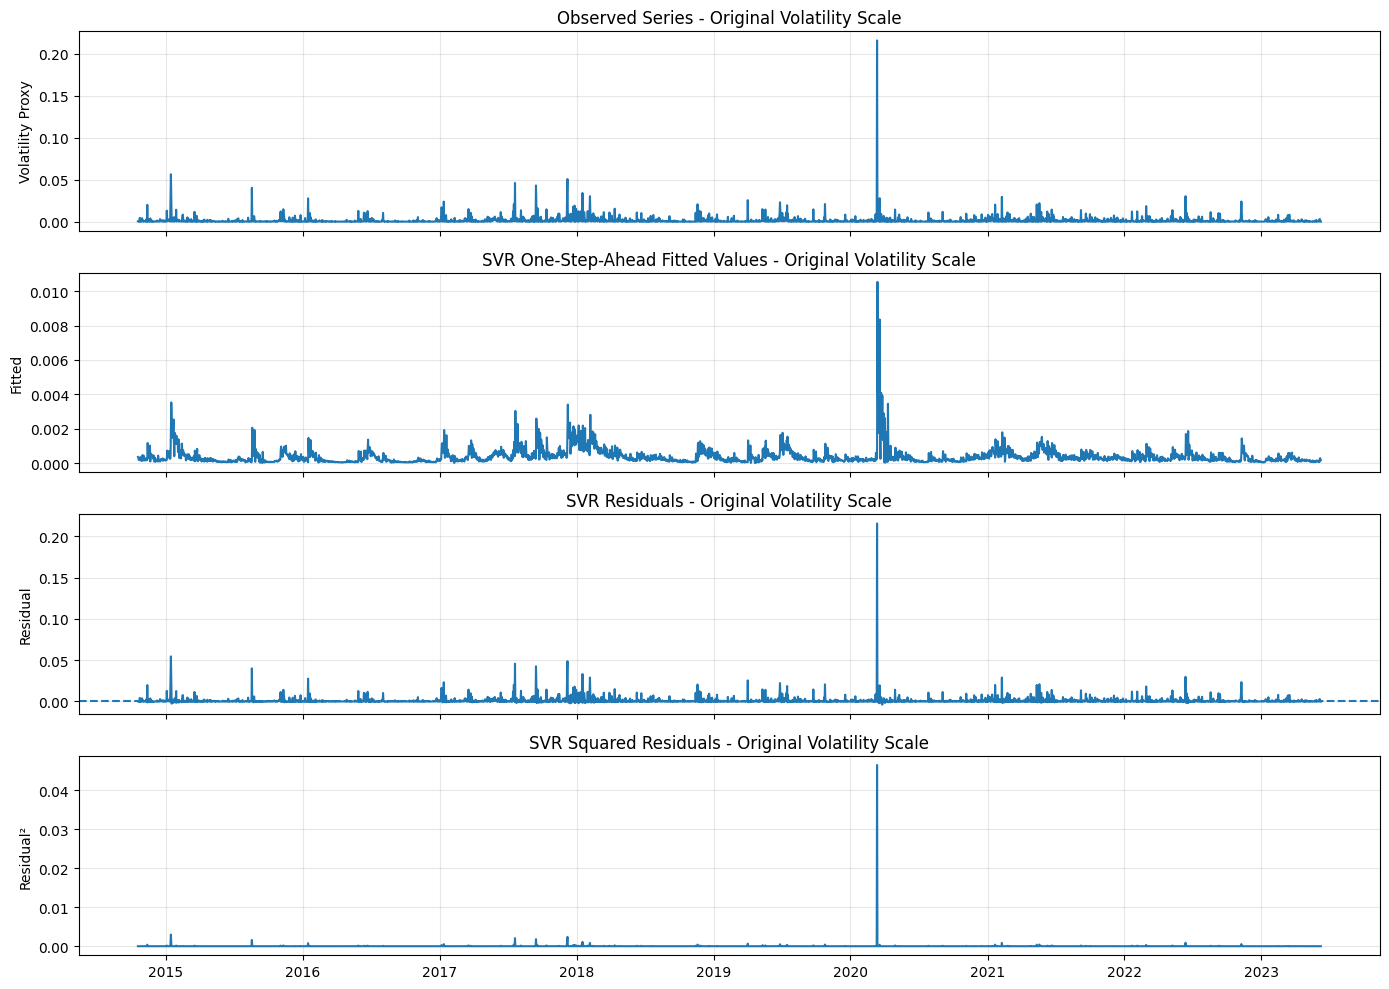

In [56]:
# Plot SVR fit diagnostics: observed, fitted, residuals and squared residuals
y_dev_used = residual_pack_svr["y_dev_used"]
fitted = residual_pack_svr["fitted_values"]
residuals = residual_pack_svr["residuals"]

# Convert observed development series to original volatility-proxy scale
y_dev_original = pd.Series(inverse_variance_transformation(values=y_dev_used.values.astype(float),
                                                           reference_series=residual_pack_svr["y_dev"],
                                                           yeo_johnson_transformer=scale_transformer,
                                                           clip_negative=True), index=y_dev_used.index, name="Observed")

# Align all series to the same index
common_index = (y_dev_original.index.intersection(fitted.index).intersection(residuals.index))

y_dev_plot = y_dev_original.loc[common_index]
fitted_plot = fitted.loc[common_index]
residuals_plot = residuals.loc[common_index]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Observed series
axes[0].plot(y_dev_plot.index, y_dev_plot.values)
axes[0].set_title("Observed Series - Original Volatility Scale")
axes[0].set_ylabel("Volatility Proxy")

# Fitted values
axes[1].plot(fitted_plot.index, fitted_plot.values)
axes[1].set_title("SVR One-Step-Ahead Fitted Values - Original Volatility Scale")
axes[1].set_ylabel("Fitted")

# Residuals
axes[2].plot(residuals_plot.index, residuals_plot.values)
axes[2].axhline(0, linestyle="--")
axes[2].set_title("SVR Residuals - Original Volatility Scale")
axes[2].set_ylabel("Residual")

# Squared residuals
axes[3].plot(residuals_plot.index, residuals_plot.values ** 2)
axes[3].set_title("SVR Squared Residuals - Original Volatility Scale")
axes[3].set_ylabel("Residual²")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---